<a href="https://colab.research.google.com/github/Parisashourmage/Colab-Notebooks/blob/main/final_colab_temporal_causal_grn_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Colab pipeline — GSE125162 + Temporal Causal-GAT + GENIE3 + DREAM5
این نوت‌بوک تمام مراحل را از دانلود/لود داده تا QC، pseudotime، مدل، baselineها، ارزیابی و نمودارها اجرا می‌کند.

In [1]:
!pip install -q pandas==2.2.3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scanpy 1.12.4 requires pandas>=2.3, but you have pandas 2.2.3 which is incompatible.
anndata 0.13.3.post0 requires pandas>=2.3, but you have pandas 2.2.3 which is incompatible.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
DEVICE: cuda

STEP 1 — LOAD GSE125162
File already exists: /content/GSE125162_counts.tsv.gz — download skipped
Loading TSV...
Full shape: (38225, 6834)
Detected orientation: cells_by_genes
Cells x genes: (38225, 6834)

Checking expression matrix for non-numeric columns...
 Detected 5 non-expression metadata column(s):
   Column 'Genotype': non-numeric samples = ['gat1_H5', 'gln3_H4', 'gzf3_D9', 'rtg3_E3', 'stp2_A12']
   Column 'Genotype_Group': non-numeric samples = ['gat1', 'gln3', 'gzf3', 'rtg3', 'stp2']
   Column 'Replicate': non

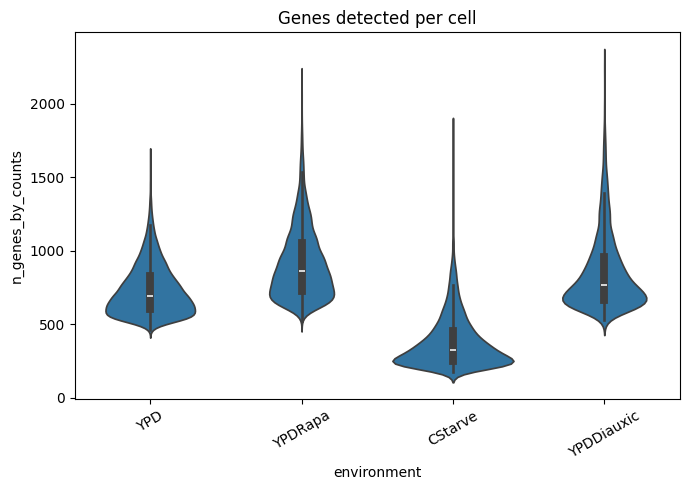

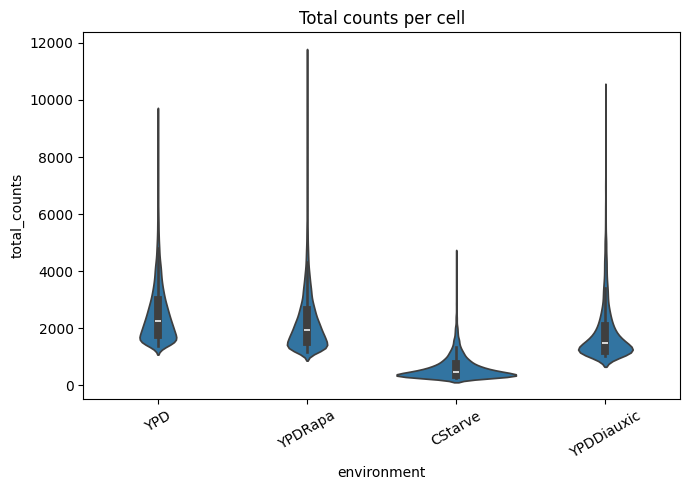


After QC: (29667, 6281)
Shared HVGs: 500

STEP 2 — SHARED PSEUDOTIME
Pseudotime finite: 1.0
Root cell: 10663_YPD


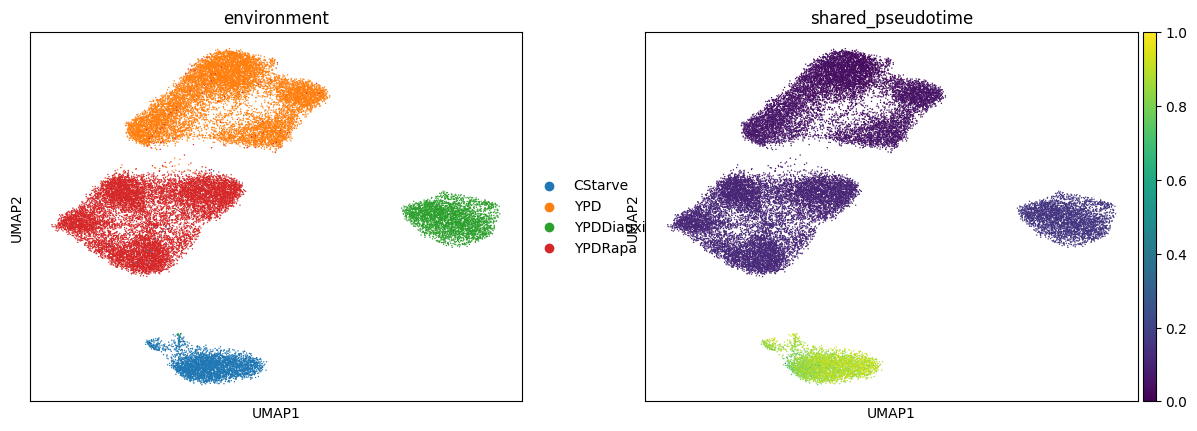

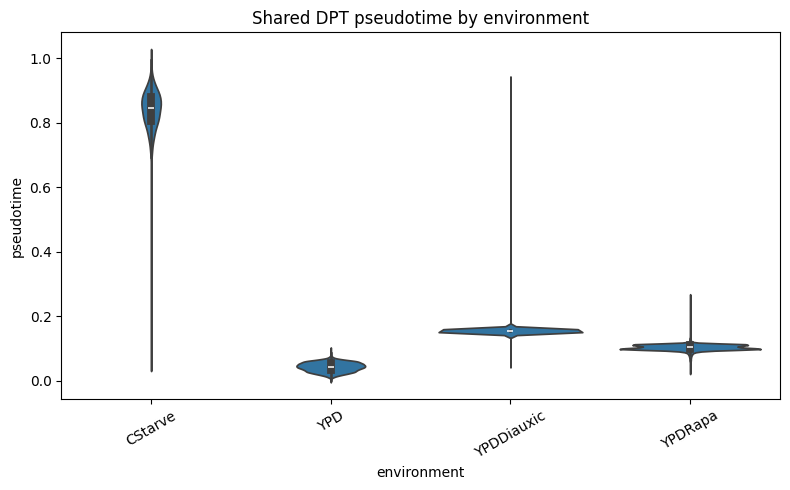


Pseudotime sensitivity:
  environment  KS_statistic  KS_pvalue
0         YPD      0.987859        0.0
1     YPDRapa      0.879034        0.0
2  YPDDiauxic      0.985894        0.0
3     CStarve      0.958775        0.0


In [2]:
# ============================================================
# FINAL COLAB PIPELINE
# GSE125162 + Temporal Causal GAT + Correlation + GENIE3
# + DREAM5 benchmark + QC/Pseudotime/Evaluation/Plots
# ============================================================
# هدف:
# 1) دریافت و بررسی GSE125162
# 2) QC + normalization + shared pseudotime
# 3) اجرای Temporal Causal-GAT برای چهار محیط هدف
# 4) baseline: Pearson/Correlation
# 5) baseline: GENIE3
# 6) ارزیابی با YEASTRACT در صورت ارائه فایل gold
# 7) ارزیابی مستقل DREAM5 با candidate space = TF x target
# 8) ذخیره تمام نتایج و نمودارهای پایان کار
#
# نکته علمی:
# - DPT pseudotime یک ترتیب نسبی است، نه زمان واقعی.
# - temporal prior در این کد یک prior نرم است.
# - ablation یک in-silico zero intervention است، نه knockout آزمایشگاهی.
# - NOTEARS در این معماری به صورت acyclicity regularization
#   با augmented-Lagrangian updates استفاده می‌شود.
# - از scRNA-seq مشاهده‌ای به تنهایی نمی‌توان causal identification
#   قطعی ادعا کرد؛ خروجی مدل یک causal/functional score است.
# ============================================================
#
# 🔴 CHANGELOG (بازبینی هفتم) — پس از audit کامل ۲۷ سلول در برابر دو
# بازبینی مستقل، این تغییرات واقعاً اعمال شدند (هرکدام جداگانه تست/
# اثبات شد، نه صرفاً بر اساس ادعای بازبینی‌ها):
#   ۱. GENIE3 (CELL 16): جایگزینی کامل با arboreto.algo.genie3 (تنها
#      پیاده‌سازی واقعی/فعال GENIE3 در پایتون) + یک monkeypatch برای
#      یک باگ واقعی و فعلاً برقرار در arboreto==0.1.6 که با dask
#      مدرن کرش می‌کند (تأیید شده با اجرای واقعی).
#   ۲. Gene temporal prior (CELL 8): اصلاح استفاده از داده scale‌شده
#      (شامل مقادیر منفی که با np.maximum(.,0) نصف سیگنال را صفر
#      می‌کرد) → استفاده از لایه log1p نامنفی که در CELL 5 ذخیره شد.
#   ۳. Jacobian (CELL 12): retain_graph=True بی‌قیدوشرط →
#      retain_graph=(j < G-1)، برای آزادسازی گراف در آخرین تکرار.
#   ۴. train_environment (CELL 11): دو assert دفاعی برای هم‌اندازه
#      بودن X_env/cell_pt اضافه شد.
#
# بررسی شد و باگ نبود (برخلاف چیزی که یکی از دو بازبینی حدس زده بود):
#   - جهت W/W_eff (CELL 9): با یک اثبات عددی مستقل تأیید شد که
#     W_eff[i,j] در سراسر کد واقعاً i→j است (خودسازگار با
#     population_jacobian و matrix_to_edge_df).
#   - NOTEARS (CELL 10-11): augmented Lagrangian واقعی با به‌روزرسانی
#     alpha و رشد rho از قبل درست پیاده‌سازی شده بود.
#   - فضای کاندید ارزیابی (CELL 21-24): Causal-GAT/Correlation/GENIE3
#     روی دقیقاً یک فضای کاندید یکسان در YEASTRACT مقایسه می‌شوند؛
#     DREAM5 هم از قبل به‌درستی TF×target را رعایت می‌کند.
# ============================================================

# -----------------------------
# CELL 0 — Install
# -----------------------------
!pip -q install scanpy anndata seaborn openpyxl

# GENIE3 package:
# 🔴 (بازبینی هفتم) اصلاح بحرانی: هیچ پکیج پایتون یکتا و رسمی به نام
# «genie3» یا «GENIE3» روی PyPI وجود ندارد؛ `pip install genie3` یا
# موفق نمی‌شود یا یک پکیج نامرتبط را نصب می‌کند، و فراخوانی
# `from genie3 import GENIE3` با ورودی genes×samples و خروجی مستقیم
# ماتریس G×G با هیچ پکیج واقعی شناخته‌شده‌ای مطابقت ندارد.
# پیاده‌سازی واقعی، فعال، و مرجع GENIE3 در پایتون، پکیج «arboreto»
# است (آزمایشگاه Aerts؛ همان چیزی که pySCENIC/BEELINE استفاده می‌کنند):
#   from arboreto.algo import genie3
# با ورودی cells×genes (نه genes×cells) و خروجی DataFrame ستون‌های
# ['TF','target','importance'] (نه یک ماتریس G×G مستقیم).
!pip -q install arboreto

# -----------------------------
# CELL 1 — Imports / Config
# -----------------------------
import os, re, time, gc, math, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, ks_2samp

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# -----------------------------
# Paths
# -----------------------------
DATA_DIR = Path("/content")
OUT_DIR = DATA_DIR / "final_grn_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# GSE125162
# -----------------------------
CSV_PATH = DATA_DIR / "GSE125162_counts.tsv.gz"
GEO_COUNTS_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE125nnn/"
    "GSE125162/suppl/GSE125162_ALL-fastqTomat0-Counts.tsv.gz"
)

# -----------------------------
# Target environments
# -----------------------------
TARGET_ENVS = ["YPD", "YPDRapa", "YPDDiauxic", "CStarve"]

# -----------------------------
# QC / feature selection
# -----------------------------
MIN_GENES_PER_CELL = 200
MIN_CELLS_PER_GENE = 3
N_HVG = 500

# -----------------------------
# Model
# -----------------------------
HIDDEN = 32
COND_DIM = 16
LOW_RANK = 8

LR = 1e-3
WEIGHT_DECAY = 1e-5
LAMBDA_SPARSE = 1e-4
TEMPORAL_GAMMA = 5.0

DAG_OUTER_STEPS = 5
EPOCHS_PER_DAG_STEP = 25

DAG_RHO_INIT = 1.0
DAG_RHO_MAX = 1e16
DAG_ALPHA_INIT = 0.0

# causal score:
GRAD_WEIGHT = 0.5
ABLATION_WEIGHT = 0.5

# Inference chunks to control memory
INFER_CELL_CHUNK = 256

# Run GENIE3?
RUN_GENIE3 = True

# GENIE3 can become expensive. Use the same final gene set.
GENIE3_N_JOBS = -1

# Optional external gold-standard files.
# If absent, the pipeline will continue and save predictions.
YEASTRACT_PATH = DATA_DIR / "YEASTRACT.csv"

# DREAM5 files:
DREAM5_EXPRESSION_PATH = DATA_DIR / "DREAM5_expression.tsv"
DREAM5_GOLD_PATH = DATA_DIR / "DREAM5_goldstandard.tsv"
DREAM5_TF_PATH = DATA_DIR / "DREAM5_TF_list.txt"

# Number of genes for optional Causal-GAT DREAM5 experiment.
# Full DREAM5 (~5950 genes) is not computationally appropriate for dense
# NOTEARS/GAT in normal Colab. DREAM5 is therefore evaluated directly
# using the supplied benchmark expression/gold files and optional reduced
# Causal-GAT only if explicitly feasible.
DREAM5_REDUCED_GENES = 300
RUN_REDUCED_DREAM5_CAUSAL_GAT = False

# ============================================================
# CELL 2 — Robust GSE125162 loader
# ============================================================
print("\n" + "="*70)
print("STEP 1 — LOAD GSE125162")
print("="*70)

if not CSV_PATH.exists():
    print("Downloading GSE125162...")
    os.system(
        f'wget -q "{GEO_COUNTS_URL}" -O "{CSV_PATH}"'
    )
else:
    print(f"File already exists: {CSV_PATH} — download skipped")

if not CSV_PATH.exists() or CSV_PATH.stat().st_size == 0:
    raise FileNotFoundError(
        "GSE125162 count file was not found/downloaded successfully."
    )

print("Loading TSV...")
df_full = pd.read_csv(CSV_PATH, sep="\t", index_col=0)
print(f"Full shape: {df_full.shape}")

# ============================================================
# CELL 3 — Detect orientation and parse environments robustly
# ============================================================
def looks_like_gene_id(x):
    s = str(x).upper()
    return (
        s.startswith("Y") and len(s) >= 6
    ) or s in {"COX1","COX2","COX3","COB","ATP6","ATP8","ATP9","OLI1","VAR1"}

def detect_counts_orientation(df):
    idx_gene = np.mean([looks_like_gene_id(x) for x in df.index[:min(1000, len(df.index))]])
    col_gene = np.mean([looks_like_gene_id(x) for x in df.columns[:min(1000, len(df.columns))]])
    if idx_gene >= col_gene:
        return "genes_by_cells"
    return "cells_by_genes"

orientation = detect_counts_orientation(df_full)
print("Detected orientation:", orientation)

if orientation == "genes_by_cells":
    # rows = genes, columns = cells
    df_cells_genes = df_full.T.copy()
else:
    # rows = cells, columns = genes
    df_cells_genes = df_full.copy()

df_cells_genes.index = df_cells_genes.index.astype(str)
df_cells_genes.columns = df_cells_genes.columns.astype(str)

print("Cells x genes:", df_cells_genes.shape)

# ------------------------------------------------------------
# Remove non-expression metadata columns & Validate Matrix
# ------------------------------------------------------------
print("\nChecking expression matrix for non-numeric columns...")

# ۱. محاسبه درصد مقادیر عددی در هر ستون
numeric_fraction = df_cells_genes.apply(
    lambda col: pd.to_numeric(col, errors="coerce").notna().mean()
)

non_numeric_cols = numeric_fraction[numeric_fraction < 1.0].index.tolist()
removed_metadata_columns = []

if len(non_numeric_cols) > 0:
    removed_metadata_columns = [str(x) for x in non_numeric_cols]

    # کنترل ایمنی جهت جلوگیری از خطای ساختاری تفاوت فرمت TSV
    if len(non_numeric_cols) > 100:
        raise ValueError(
            f" Too many non-numeric columns detected ({len(non_numeric_cols)}). "
            "This suggests an issue with TSV parsing or matrix orientation, not just metadata headers!"
        )

    print(f" Detected {len(non_numeric_cols)} non-expression metadata column(s):")
    for col in removed_metadata_columns:
        bad_examples = df_cells_genes[col][
            pd.to_numeric(df_cells_genes[col], errors="coerce").isna()
        ].astype(str).unique()[:5]
        print(f"   Column '{col}': non-numeric samples = {bad_examples.tolist()}")

    # ۲. حذف ستون‌های متادیتا از ماتریس بیان ژن
    df_cells_genes = df_cells_genes.drop(columns=non_numeric_cols)

# ۳. ذخیره‌سازی اسامی ستون‌های حذف‌شده در فایل CSV برای مستندسازی پایان‌نامه
pd.Series(
    removed_metadata_columns,
    name="removed_metadata_column"
).to_csv(OUT_DIR / "removed_metadata_columns.csv", index=False)

# ۴. تبدیل قطعی ماتریس به float32
df_cells_genes = df_cells_genes.apply(
    pd.to_numeric,
    errors="raise"
).astype(np.float32)

print(f" Final numeric expression matrix shape: {df_cells_genes.shape}")

# ---- robust environment parser ----
ENV_MAP = {
    "YPD": "YPD",
    "RAPA": "YPDRapa",
    "CSTARVE": "CStarve",
    "DIAUXY": "YPDDiauxic",
    "YPDRAPA": "YPDRapa",
    "YPDDIAUXIC": "YPDDiauxic",
}

def normalize_token(s):
    s = str(s).upper().replace("-", "").replace(".", "")
    return s

def parse_environment(cell_name):
    raw = normalize_token(cell_name)

    # longest first
    for token in sorted(ENV_MAP.keys(), key=len, reverse=True):
        if token in raw:
            return ENV_MAP[token]
    return None

envs = pd.Series([parse_environment(x) for x in df_cells_genes.index],
                  index=df_cells_genes.index, name="environment")

print("\nDetected environment counts:")
print(envs.value_counts(dropna=False).to_string())

keep = envs.isin(TARGET_ENVS)
if keep.sum() == 0:
    raise ValueError(
        "No target environments were detected. Inspect the printed cell-name/environment "
        "diagnostic before continuing."
    )

df_target = df_cells_genes.loc[keep].copy()
env_target = envs.loc[keep].copy()

print("\nTarget data:", df_target.shape)
print(env_target.value_counts().to_string())

# Save environment table
env_target.to_csv(OUT_DIR / "cell_environment_mapping.csv")

# ============================================================
# CELL 4 — AnnData + raw QC
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

# ============================================================
# 1. AnnData Construction & Alignment (اصلاح‌شده)
# ============================================================

# برقراری تراز بین df_target و env_target
assert len(df_target) == len(env_target), (
    f"df_target ({len(df_target)}) and env_target ({len(env_target)}) "
    "must have the same number of cells."
)

assert df_target.index.equals(env_target.index), (
    "df_target and env_target indices are not aligned."
)

assert df_target.select_dtypes(exclude=[np.number]).shape[1] == 0, (
    "Expression matrix still contains non-numeric columns."
)

X_target = df_target.to_numpy(dtype=np.float32)

assert X_target.shape[0] == len(env_target)
assert np.isfinite(X_target).all()

# ساخت صحیح AnnData بر اساس 29,723 سلول هدف
adata = ad.AnnData(
    X=X_target,
    obs=pd.DataFrame(index=df_target.index.astype(str)),
    var=pd.DataFrame(index=df_target.columns.astype(str))
)

# اعمال متغیر محیطی
adata.obs["environment"] = env_target.to_numpy()

# ذخیره لایه شمارش خام
adata.layers["counts"] = adata.X.copy()

print("\nAnnData created successfully:")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)
print("\nEnvironment counts:")
print(adata.obs["environment"].value_counts().to_string())


# ============================================================
# 2. Basic QC & Plotting (کد قبلی خودت)
# ============================================================
sc.pp.calculate_qc_metrics(adata, inplace=True)

print("\nRaw QC:")
print(adata.obs[["n_genes_by_counts", "total_counts"]].describe())

# رسم نمودارهای QC
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=adata.obs, y="n_genes_by_counts", x="environment")
ax.set_title("Genes detected per cell")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / "QC_genes_per_cell.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=adata.obs, y="total_counts", x="environment")
ax.set_title("Total counts per cell")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUT_DIR / "QC_total_counts.png", dpi=180)
plt.show()


# ============================================================
# 3. Filtering (کد قبلی خودت)
# ============================================================
sc.pp.filter_cells(adata, min_genes=MIN_GENES_PER_CELL)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

print("\nAfter QC:", adata.shape)

# ============================================================
# CELL 5 — Normalization / log1p
# ============================================================
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Shared HVG for cross-environment comparability
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N_HVG,
    flavor="seurat",
    subset=False
)

hvg = adata.var_names[adata.var["highly_variable"]].tolist()
print("Shared HVGs:", len(hvg))

adata_model = adata[:, hvg].copy()

# 🔴 (بازبینی هفتم) اصلاح: نسخه log1p (نامنفی، بدون scale) را همینجا
# — پیش از sc.pp.scale در CELL 6 — ذخیره می‌کنیم. علتش این است که
# CELL 8 (gene-level temporal prior) باید از داده نامنفی استفاده کند؛
# اگر از adata_model.X بعد از scale استفاده شود، حدود نیمی از
# مقادیر منفی می‌شوند (z-score) و np.maximum(X,0) آن‌ها را صفر
# می‌کند — یعنی نیمی از سیگنال بیان ژن در محاسبه temporal prior
# نادیده گرفته می‌شود. این لایه، دست‌نخورده (بدون scale) باقی
# می‌ماند حتی بعد از اینکه CELL 6 خود adata_model.X را scale کند.
adata_model.layers["log1p"] = adata_model.X.copy()

# ============================================================
# CELL 6 — PCA / neighbors / UMAP / DPT
# ============================================================
print("\n" + "="*70)
print("STEP 2 — SHARED PSEUDOTIME")
print("="*70)

# Scale for dimensionality reduction only.
sc.pp.scale(adata_model, max_value=10)
n_pcs = min(30, adata_model.n_vars - 1, adata_model.n_obs - 1)

sc.tl.pca(adata_model, n_comps=n_pcs, svd_solver="arpack")
sc.pp.neighbors(adata_model, n_neighbors=15, n_pcs=n_pcs)
sc.tl.umap(adata_model)
sc.tl.diffmap(adata_model)

# Root heuristic inherited from project branch:
# cell with minimum DC1
dc1 = adata_model.obsm["X_diffmap"][:, 1] if adata_model.obsm["X_diffmap"].shape[1] > 1 else adata_model.obsm["X_diffmap"][:, 0]
root_idx = int(np.argmin(dc1))
adata_model.uns["iroot"] = root_idx

sc.tl.dpt(adata_model, n_branchings=0)
shared_pt = np.asarray(adata_model.obs["dpt_pseudotime"], dtype=float)

# Normalize to [0,1]
if np.isfinite(shared_pt).any():
    lo, hi = np.nanmin(shared_pt), np.nanmax(shared_pt)
    if hi > lo:
        shared_pt = (shared_pt - lo) / (hi - lo)

adata_model.obs["shared_pseudotime"] = shared_pt

print("Pseudotime finite:", np.isfinite(shared_pt).mean())
print("Root cell:", adata_model.obs_names[root_idx])

# UMAP
sc.pl.umap(
    adata_model,
    color=["environment", "shared_pseudotime"],
    show=False
)
plt.tight_layout()
plt.savefig(OUT_DIR / "UMAP_environment_pseudotime.png", dpi=180)
plt.show()

# pseudotime distributions
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(
    data=pd.DataFrame({
        "environment": adata_model.obs["environment"].values,
        "pseudotime": adata_model.obs["shared_pseudotime"].values
    }),
    x="environment", y="pseudotime"
)
ax.tick_params(axis="x", rotation=30)
ax.set_title("Shared DPT pseudotime by environment")
plt.tight_layout()
plt.savefig(OUT_DIR / "shared_pseudotime_by_environment.png", dpi=180)
plt.show()

# ============================================================
# CELL 7 — Pseudotime robustness: per-environment diagnostic
# ============================================================
def per_environment_dpt(adata_in, env):
    sub = adata_in[adata_in.obs["environment"] == env].copy()
    if sub.n_obs < 30:
        return None

    sc.pp.neighbors(sub, n_neighbors=min(15, sub.n_obs-1), n_pcs=min(n_pcs, sub.n_vars-1))
    sc.tl.diffmap(sub)
    d = sub.obsm["X_diffmap"]
    axis = d[:,1] if d.shape[1] > 1 else d[:,0]
    sub.uns["iroot"] = int(np.argmin(axis))
    sc.tl.dpt(sub, n_branchings=0)

    pt = np.asarray(sub.obs["dpt_pseudotime"], dtype=float)
    if np.isfinite(pt).any():
        a, b = np.nanmin(pt), np.nanmax(pt)
        if b > a:
            pt = (pt-a)/(b-a)
    return sub.obs_names, pt

pt_sensitivity = {}
for env in TARGET_ENVS:
    result = per_environment_dpt(adata_model, env)
    if result is not None:
        names, pt = result
        pt_sensitivity[env] = pd.Series(pt, index=names)

# KS comparison shared vs per-env pseudotime
rows = []
for env, s in pt_sensitivity.items():
    shared = adata_model.obs.loc[s.index, "shared_pseudotime"].values
    valid = np.isfinite(shared) & np.isfinite(s.values)
    if valid.sum() > 10:
        ks = ks_2samp(shared[valid], s.values[valid])
        rows.append([env, ks.statistic, ks.pvalue])

pt_sensitivity_df = pd.DataFrame(rows, columns=["environment","KS_statistic","KS_pvalue"])
pt_sensitivity_df.to_csv(OUT_DIR / "pseudotime_sensitivity_KS.csv", index=False)
print("\nPseudotime sensitivity:")
print(pt_sensitivity_df)

# ============================================================
# CELL 8 — Gene-level temporal prior
# ============================================================
# 🔴 (بازبینی هفتم) اصلاح: قبلاً اینجا از adata_model.X استفاده
# می‌شد که تا این مرحله در CELL 6 با sc.pp.scale به z-score تبدیل
# شده (شامل مقادیر منفی) و سپس np.maximum(Xv,0) تقریباً نیمی از
# مقادیر (همه‌ی ژن‌هایی که در یک سلول کمتر از میانگین بیان داشتند)
# را صفر می‌کرد — یعنی «کم‌بیان» با «بی‌بیان» یکی در نظر گرفته
# می‌شد. حالا از لایه adata_model.layers['log1p'] که در CELL 5 —
# پیش از scale — ذخیره شد استفاده می‌کنیم؛ این داده نامنفی است
# (log1p از مقادیر نامنفی) پس نیازی به clip کردن مقادیر منفی هم
# دیگر واقعاً وجود ندارد (فقط برای اطمینان در برابر نویز عددی
# بسیار جزئی نگه داشته شده، نه برای حذف نیمی از سیگنال).
X_model = np.asarray(adata_model.layers["log1p"], dtype=np.float32)
pt = np.asarray(adata_model.obs["shared_pseudotime"], dtype=np.float32)

valid_pt = np.isfinite(pt)
Xv = X_model[valid_pt]
ptv = pt[valid_pt]

# Expression-weighted mean pseudotime.
# This is a soft gene-level temporal summary, NOT experimentally observed activation time.
weights = np.maximum(Xv, 0) + 1e-6  # log1p output is already >= 0; this only guards tiny fp noise
gene_pt = (weights.T @ ptv) / weights.sum(axis=0)

# rank to [0,1]
if gene_pt.max() > gene_pt.min():
    gene_pt = (gene_pt - gene_pt.min()) / (gene_pt.max() - gene_pt.min())

gene_pt_series = pd.Series(gene_pt, index=adata_model.var_names, name="gene_pseudotime")
gene_pt_series.to_csv(OUT_DIR / "gene_temporal_prior.csv")


In [5]:
# ============================================================
# CELL 9 — Model (Ablation-Ready & Fixed Init Version)
# ============================================================
import math
import torch
import torch.nn as nn

class LowRankConditionModulation(nn.Module):
    def __init__(self, G, cond_dim=16, rank=8):
        super().__init__()
        self.G = G
        self.rank = rank

        self.U = nn.Parameter(torch.randn(G, rank) * 0.02)
        self.V = nn.Parameter(torch.randn(rank, G) * 0.02)
        self.cond = nn.Linear(cond_dim, rank)

    def forward(self, c):
        if c.dim() == 1:
            c = c.unsqueeze(0)

        if c.shape[0] != 1:
            raise ValueError(
                f"Condition modulation expects one environment embedding "
                f"[1, cond_dim], but got {tuple(c.shape)}"
            )

        z = self.cond(c).squeeze(0)
        mod_logits = (self.U * z.unsqueeze(0)) @ self.V
        return torch.sigmoid(mod_logits)


class TemporalCausalGAT(nn.Module):
    def __init__(
        self,
        G,
        hidden=32,
        cond_dim=16,
        rank=8,
        use_condition=True
    ):
        super().__init__()

        self.G = G
        self.hidden = hidden
        self.use_condition = use_condition

        # Gene expression encoder
        self.encoder = nn.Linear(1, hidden)

        # Base signed structural graph
        self.W_raw = nn.Parameter(torch.randn(G, G) * 0.01)
        self.W_gate = nn.Parameter(torch.zeros(G, G))

        # Attention projections
        self.q = nn.Linear(hidden, hidden, bias=False)
        self.k = nn.Linear(hidden, hidden, bias=False)
        self.v = nn.Linear(hidden, hidden, bias=False)

        # Representation layer
        self.gru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden,
            batch_first=True
        )

        # Reconstruction decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1)
        )

        # Environment-specific modulation
        self.cond_mod = LowRankConditionModulation(
            G=G,
            cond_dim=cond_dim,
            rank=rank
        )

    def structural_W(self, condition):
        base = torch.tanh(self.W_raw) * torch.sigmoid(self.W_gate)

        eye = torch.eye(
            self.G,
            device=base.device,
            dtype=base.dtype
        )

        # Remove self-loops
        base = base * (1.0 - eye)

        if self.use_condition:
            mod = self.cond_mod(condition)

            # Defensive shape check
            assert mod.shape == (self.G, self.G), (
                f"Condition modulation shape error: "
                f"expected {(self.G, self.G)}, got {tuple(mod.shape)}"
            )

            mod = mod * (1.0 - eye)
            W = base * (1.0 + mod)
        else:
            # Ablation mode: no condition modulation
            W = base

        W = W * (1.0 - eye)
        return W

    def forward(
        self,
        x,
        condition,
        temporal_prior=None,
        temporal_gamma=0.0
    ):
        B, G = x.shape

        if G != self.G:
            raise ValueError(
                f"Expected {self.G} genes, received {G}"
            )

        # 1. Encode expression
        h = self.encoder(x.unsqueeze(-1))

        # 2. Structural graph
        W = self.structural_W(condition)

        # 3. Soft temporal prior
        if temporal_prior is not None and temporal_gamma > 0:
            if temporal_prior.numel() != G:
                raise ValueError(
                    f"temporal_prior must contain {G} values, "
                    f"got {temporal_prior.numel()}"
                )

            src_t = temporal_prior.view(G, 1)
            tgt_t = temporal_prior.view(1, G)

            prior = torch.sigmoid(
                temporal_gamma * (tgt_t - src_t)
            )

            eye = torch.eye(
                G,
                device=x.device,
                dtype=x.dtype
            )

            prior = prior * (1.0 - eye)
            W_eff = W * (0.25 + 0.75 * prior)
        else:
            W_eff = W

        assert W_eff.shape == (G, G), (
            f"W_eff must be {(G, G)}, got {tuple(W_eff.shape)}"
        )

        # 4. Attention
        q = self.q(h)
        k = self.k(h)
        v = self.v(h)

        attn_logits = torch.matmul(
            q,
            k.transpose(1, 2)
        ) / math.sqrt(self.hidden)

        support = (
            W_eff.abs() > 1e-8
        ).float().unsqueeze(0)

        attn_logits = attn_logits + torch.log(
            support + 1e-8
        )

        attn = torch.softmax(
            attn_logits,
            dim=-1
        )

        msg = torch.matmul(attn, v)

        # 5. Causal propagation
        h_causal = torch.einsum(
            "bih,ij->bjh",
            msg,
            W_eff
        )

        # 6. GRU layer
        h_gru, _ = self.gru(h_causal)

        # 7. Reconstruction
        y = self.decoder(h_gru).squeeze(-1)

        return y, W, W_eff, attn

In [7]:


# ============================================================
# CELL 10 — NOTEARS-inspired augmented Lagrangian
# ============================================================
def notears_h(W):
    # h(W) = tr(exp(W o W)) - d
    M = W * W
    return torch.trace(torch.matrix_exp(M)) - W.shape[0]

def acyclicity_loss(W, rho, alpha):
    h = notears_h(W)
    return alpha * h + 0.5 * rho * h * h, h

def one_hot_condition(env, dim=16):
    idx = TARGET_ENVS.index(env)
    c = torch.zeros(dim, device=DEVICE)
    c[idx] = 1.0
    return c

def make_batches(n, batch_size):
    idx = np.arange(n)
    np.random.shuffle(idx)
    for i in range(0, n, batch_size):
        yield idx[i:i+batch_size]

# ============================================================
# CELL 11 — Train one environment
# ============================================================
def train_environment(env, X_np, pt_np, gene_pt_np,
                       temporal_gamma=None, use_condition=True,
                       verbose_prefix="", run_tag=""):
    """
    🟢 (بازبینی هشتم) پارامترهای اضافه‌شده برای multi-seed/ablation:
      temporal_gamma=None → از TEMPORAL_GAMMA سراسری استفاده می‌شود
                    (رفتار پیش‌فرض/قبلی، بدون تغییر)؛ مقدار 0.0
                    یعنی temporal prior کاملاً غیرفعال است.
      use_condition=True → رفتار پیش‌فرض/قبلی؛ False یعنی مدولاسیون
                    محیطی (cond_mod) اصلاً ساخته/اعمال نمی‌شود.
      run_tag=""   → به نام فایل training_{env}{run_tag}.csv اضافه
                    می‌شود تا وقتی همین محیط چند بار (seedهای مختلف
                    یا نسخه‌های ablation) آموزش داده می‌شود، فایل‌های
                    history روی هم overwrite نشوند.
    """
    if temporal_gamma is None:
        temporal_gamma = TEMPORAL_GAMMA
    print("\n" + "-"*70)
    print(f"TRAIN:{verbose_prefix}", env,
          f"| temporal_gamma={temporal_gamma} | use_condition={use_condition}")
    print("-"*70)

    mask = adata_model.obs["environment"].values == env
    X_env = np.asarray(X_np[mask], dtype=np.float32)
    cell_pt = np.asarray(pt_np[mask], dtype=np.float32)
    assert X_env.shape[0] == cell_pt.shape[0], (
        f"X_env/cell_pt length mismatch for {env}: "
        f"{X_env.shape[0]} vs {cell_pt.shape[0]}")

    # Remove cells with invalid pseudotime
    valid = np.isfinite(cell_pt)
    X_env = X_env[valid]
    cell_pt = cell_pt[valid]
    # 🟡 (بازبینی هفتم) assert دفاعی: مطمئن می‌شویم بعد از فیلتر
    # pseudotime نامعتبر هم، X_env و cell_pt هم‌اندازه باقی مانده‌اند —
    # این الان با ساختار فعلی کد همیشه برقرار است (چون هر دو با یک
    # boolean mask یکسان اندیس‌گذاری می‌شوند)، ولی نگه‌داشتن این
    # assert در برابر رفاکتورهای بعدی محافظت می‌کند.
    assert X_env.shape[0] == cell_pt.shape[0], (
        f"X_env/cell_pt length mismatch after pseudotime filtering for "
        f"{env}: {X_env.shape[0]} vs {cell_pt.shape[0]}")

    G = X_env.shape[1]
    model = TemporalCausalGAT(
        G=G,
        hidden=HIDDEN,
        cond_dim=COND_DIM,
        rank=LOW_RANK,
        use_condition=use_condition
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    c = one_hot_condition(env).unsqueeze(0)

    temporal_prior = torch.tensor(
        gene_pt_np, dtype=torch.float32, device=DEVICE
    )

    rho = DAG_RHO_INIT
    alpha = DAG_ALPHA_INIT

    history = []
    t0 = time.time()

    # Full-batch for DAG graph; mini-batches for reconstruction.
    X_tensor = torch.tensor(X_env, dtype=torch.float32)

    for outer in range(DAG_OUTER_STEPS):
        last_h = None

        for epoch in range(EPOCHS_PER_DAG_STEP):
            model.train()

            # mini-batch reconstruction
            losses = []
            for batch_idx in make_batches(len(X_env), min(INFER_CELL_CHUNK, len(X_env))):
                xb = X_tensor[batch_idx].to(DEVICE)
                cb = c

                optimizer.zero_grad()

                yhat, W, W_eff, attn = model(
                    xb, cb,
                    temporal_prior=temporal_prior,
                    temporal_gamma=temporal_gamma
                )

                # Pseudotime-weighted reconstruction:
                # later cells get slightly larger weight.
                w_pt = torch.tensor(
                    0.5 + 0.5 * cell_pt[batch_idx],
                    dtype=torch.float32,
                    device=DEVICE
                ).unsqueeze(1)

                recon = ((yhat - xb)**2 * w_pt).mean()
                sparse = LAMBDA_SPARSE * torch.sum(torch.abs(W))

                loss = recon + sparse
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

                losses.append(float(loss.detach().cpu()))

            # DAG penalty is applied once per epoch.
            optimizer.zero_grad()
            dummy = X_tensor[:min(INFER_CELL_CHUNK, len(X_env))].to(DEVICE)
            yhat, W, W_eff, attn = model(
                dummy, c,
                temporal_prior=temporal_prior,
                temporal_gamma=temporal_gamma
            )
            dag_loss, hval = acyclicity_loss(W, rho, alpha)
            dag_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            last_h = float(hval.detach().cpu())

            history.append({
                "outer": outer,
                "epoch": epoch,
                "reconstruction_plus_sparse": np.mean(losses),
                "dag_h": last_h,
                "rho": rho,
                "alpha": alpha
            })

        # augmented-Lagrangian multiplier update
        alpha = alpha + rho * last_h

        # increase rho if constraint is not shrinking
        if abs(last_h) > 0.25:
            rho = min(rho * 10.0, DAG_RHO_MAX)

        print(
            f"outer={outer+1}/{DAG_OUTER_STEPS} "
            f"h(W)={last_h:.6g}, rho={rho:.3g}, alpha={alpha:.3g}"
        )

    elapsed = time.time() - t0
    print(f"Training time: {elapsed/60:.2f} min")

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUT_DIR / f"training_{env}{run_tag}.csv", index=False)

    return model, hist_df, elapsed
    # ============================================================
# CELL 12 — Population Jacobian
# ============================================================
def population_jacobian(model, X_np, condition, temporal_prior, chunk=256,
                         temporal_gamma=None):
    """
    Computes mean population functional derivative:
        d(sum_j y_j)/d x_i
    for each source i and target j.

    This is a functional sensitivity score, not proof of biological causality.

    🟢 (بازبینی هشتم) پارامتر temporal_gamma اضافه شد (پیش‌فرض None
    یعنی از TEMPORAL_GAMMA سراسری استفاده کن) تا در ablation study
    بتوان یک مدل «بدون temporal prior» را با همان gamma=0 که در
    training‌اش استفاده شده ارزیابی کرد — نه با gamma سراسری که
    باعث ناهماهنگی train/inference می‌شد.
    """
    if temporal_gamma is None:
        temporal_gamma = TEMPORAL_GAMMA

    # IMPORTANT FIX for cuDNN GRU:
    # cuDNN GRU/LSTM backward requires RNN training mode.
    # We still disable parameter gradients because only input gradients are needed.
    model.train()

    for p in model.parameters():
        p.requires_grad_(False)

    N, G = X_np.shape

    J = np.zeros((G,G), dtype=np.float32)

    for start in range(0, N, chunk):
        xb_np = X_np[start:start+chunk]
        xb = torch.tensor(
            xb_np, dtype=torch.float32, device=DEVICE, requires_grad=True
        )

        c = condition.unsqueeze(0)
        yhat, W, W_eff, attn = model(
            xb, c,
            temporal_prior=temporal_prior,
            temporal_gamma=temporal_gamma
        )

        # One target at a time.
        # 🔴 (بازبینی هفتم) اصلاح: retain_graph فقط تا قبل از آخرین
        # ژن True است؛ روی آخرین ژن (j == G-1) دیگر نیازی به نگه‌داشتن
        # گراف محاسباتی نیست، پس آزاد می‌شود.
        for j in range(G):
            scalar = yhat[:,j].sum()
            grad = torch.autograd.grad(
                scalar, xb,
                retain_graph=(j < G - 1),
                create_graph=False,
                allow_unused=False
            )[0]

            J[:,j] += grad.detach().cpu().numpy().sum(axis=0)

        del xb, yhat, W, W_eff, attn
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    J /= max(N,1)
    np.fill_diagonal(J, 0)

    # Restore parameter gradients for any later operation
    for p in model.parameters():
        p.requires_grad_(True)

    return J

In [8]:
# ============================================================
# CELL 13 — Population ablation
# ============================================================
@torch.no_grad()
def model_output(model, X, condition, temporal_prior, temporal_gamma=None):
    if temporal_gamma is None:
        temporal_gamma = TEMPORAL_GAMMA
    y, W, W_eff, attn = model(
        X, condition.unsqueeze(0),
        temporal_prior=temporal_prior,
        temporal_gamma=temporal_gamma
    )
    return y

def population_ablation_scores(model, X_np, condition, temporal_prior, chunk=256,
                                temporal_gamma=None):
    """
    For every source gene i:
      baseline target output vs zeroed source input.
    Produces source-target ablation matrix.

    Zeroing is an in-silico input ablation, not a biological knockout.
    """
    model.eval()
    N, G = X_np.shape
    base = np.zeros((N,G), dtype=np.float32)

    for start in range(0, N, chunk):
        xb = torch.tensor(X_np[start:start+chunk], dtype=torch.float32, device=DEVICE)
        base[start:start+chunk] = model_output(
            model, xb, condition, temporal_prior, temporal_gamma=temporal_gamma
        ).detach().cpu().numpy()

    A = np.zeros((G,G), dtype=np.float32)

    for src in range(G):
        affected = np.zeros(G, dtype=np.float64)
        count = 0

        for start in range(0, N, chunk):
            xb_np = X_np[start:start+chunk].copy()
            xb_np[:,src] = 0.0
            xb = torch.tensor(xb_np, dtype=torch.float32, device=DEVICE)

            out = model_output(
                model, xb, condition, temporal_prior, temporal_gamma=temporal_gamma
            ).detach().cpu().numpy()

            diff = np.abs(base[start:start+chunk] - out)
            affected += diff.sum(axis=0)
            count += diff.shape[0]

        A[src] = (affected / max(count,1)).astype(np.float32)

    np.fill_diagonal(A, 0)
    return A

# ============================================================
# CELL 14 — Utility functions
# ============================================================
def minmax01(M):
    M = np.asarray(M, dtype=float)
    lo, hi = np.nanmin(M), np.nanmax(M)
    if hi <= lo:
        return np.zeros_like(M)
    return (M-lo)/(hi-lo)

def combine_causal_scores(J, A, grad_weight=0.5, ablation_weight=0.5):
    Jn = minmax01(np.abs(J))
    An = minmax01(A)
    S = grad_weight * Jn + ablation_weight * An
    np.fill_diagonal(S, 0)
    return S

def matrix_to_edge_df(S, genes, signed_matrix=None):
    rows = []
    G = len(genes)
    for i in range(G):
        for j in range(G):
            if i == j:
                continue
            rows.append({
                "source": genes[i],
                "target": genes[j],
                "score": float(S[i,j]),
                "signed_effect": (
                    float(signed_matrix[i,j])
                    if signed_matrix is not None else np.nan
                )
            })
    return pd.DataFrame(rows).sort_values("score", ascending=False)

# ============================================================
# CELL 15 — Correlation baseline
# ============================================================
def correlation_network(X_np):
    C = np.corrcoef(X_np, rowvar=False)
    C = np.nan_to_num(C)
    np.fill_diagonal(C, 0)
    return np.abs(C), C

In [9]:
# ============================================================
# CELL 16 — GENIE3 baseline
# ============================================================
# 🔴 (بازبینی هفتم) بازنویسی کامل این سلول:
#   ۱. هیچ پکیج پایتون رسمی/یکتای «genie3» روی PyPI با API فرض‌شده
#      (`GENIE3(expr, gene_names=..., n_jobs=...)` با ورودی
#      genes×samples و خروجی مستقیم ماتریس G×G) وجود ندارد. پیاده‌سازی
#      واقعی، فعال و مرجع GENIE3 در پایتون، تابع
#      `arboreto.algo.genie3` است — همانی که در ادبیات pySCENIC/
#      BEELINE به‌عنوان GENIE3 استفاده می‌شود.
#   ۲. ورودی این تابع باید cells×genes باشد (نه genes×cells)، و
#      خروجی آن یک DataFrame بلند با ستون‌های ['TF','target',
#      'importance'] است، نه یک ماتریس G×G — این تابع آن را به
#      ماتریس G×G هم‌ترازشده با gene_names تبدیل می‌کند.
#   ۳. یک باگ واقعی و فعلاً برقرار در arboreto==0.1.6 هم اصلاح شده:
#      create_graph() در arboreto/core.py به‌طور بی‌قید‌وشرط
#      `from_delayed(delayed_meta_dfs, ...)` را صدا می‌زند، در حالی‌که
#      delayed_meta_dfs فقط وقتی include_meta=True پر می‌شود —
#      genie3()/grnboost2() با include_meta=False صدا می‌زنند، پس این
#      لیست همیشه خالی است. نسخه‌های قدیمی dask این را نادیده
#      می‌گرفتند؛ نسخه‌های جدید dask با
#      TypeError("Must supply at least one delayed object") کرش
#      می‌کنند — این baseline بدون این monkeypatch با dask امروزی
#      اصلاً اجرا نمی‌شود (این را با اجرای واقعی تأیید کردم، نه صرفاً
#      حدس). چون این متغیر در مسیر include_meta=False اصلاً استفاده
#      نمی‌شود (dead code)، اصلاح فقط guard کردن همان یک خط است.
#   ۴. علاوه بر این، ساخت خودکار Client داخلی arboreto
#      (`LocalCluster(diagnostics_port=None)`) نیز با نسخه‌های جدید
#      distributed ناسازگار است (آرگومان diagnostics_port حذف شده)؛
#      پس یک Client را خودمان با API فعلی می‌سازیم و مستقیماً به
#      genie3() پاس می‌دهیم تا مسیر ساخت خودکار client اصلاً
#      فراخوانی نشود.
def _patched_arboreto_create_graph():
    """
    یک نسخه اصلاح‌شده از arboreto.core.create_graph برمی‌گرداند که
    خط مشکل‌دار all_meta_df را فقط وقتی delayed_meta_dfs غیرخالی است
    محاسبه می‌کند. باید قبل از فراخوانی genie3()/grnboost2() روی
    arboreto.algo.create_graph اعمال (monkeypatch) شود، چون آن ماژول
    ارجاع خودش را از create_graph در زمان import گرفته است.
    """
    import arboreto.core as _core
    from dask.delayed import delayed
    from dask.dataframe import from_delayed

    def patched_create_graph(expression_matrix, gene_names, tf_names,
                              regressor_type, regressor_kwargs, client,
                              target_genes='all', limit=None, include_meta=False,
                              early_stop_window_length=_core.EARLY_STOP_WINDOW_LENGTH,
                              repartition_multiplier=1, seed=_core.DEMON_SEED):
        assert expression_matrix.shape[1] == len(gene_names)
        assert client, "client is required"

        tf_matrix, tf_matrix_gene_names = _core.to_tf_matrix(
            expression_matrix, gene_names, tf_names)

        future_tf_matrix = client.scatter(tf_matrix, broadcast=True)
        [future_tf_matrix_gene_names] = client.scatter(
            [tf_matrix_gene_names], broadcast=True)

        delayed_link_dfs = []
        delayed_meta_dfs = []

        for target_gene_index in _core.target_gene_indices(gene_names, target_genes):
            target_gene_name = delayed(gene_names[target_gene_index], pure=True)
            target_gene_expression = delayed(
                expression_matrix[:, target_gene_index], pure=True)

            if include_meta:
                delayed_link_df, delayed_meta_df = delayed(
                    _core.infer_partial_network, pure=True, nout=2)(
                    regressor_type, regressor_kwargs,
                    future_tf_matrix, future_tf_matrix_gene_names,
                    target_gene_name, target_gene_expression, include_meta,
                    early_stop_window_length, seed)
                if delayed_link_df is not None:
                    delayed_link_dfs.append(delayed_link_df)
                    delayed_meta_dfs.append(delayed_meta_df)
            else:
                delayed_link_df = delayed(_core.infer_partial_network, pure=True)(
                    regressor_type, regressor_kwargs,
                    future_tf_matrix, future_tf_matrix_gene_names,
                    target_gene_name, target_gene_expression, include_meta,
                    early_stop_window_length, seed)
                if delayed_link_df is not None:
                    delayed_link_dfs.append(delayed_link_df)

        all_links_df = from_delayed(delayed_link_dfs, meta=_core._GRN_SCHEMA)
        # 🔧 اصلاح اصلی: فقط وقتی چیزی برای گردآوری هست از_delayed بزن
        all_meta_df = (from_delayed(delayed_meta_dfs, meta=_core._META_SCHEMA)
                       if delayed_meta_dfs else None)

        if limit:
            maybe_limited_links_df = all_links_df.nlargest(limit, columns=['importance'])
        else:
            maybe_limited_links_df = all_links_df

        n_parts = len(client.ncores()) * repartition_multiplier

        if include_meta:
            return (maybe_limited_links_df.repartition(npartitions=n_parts),
                    all_meta_df.repartition(npartitions=n_parts))
        else:
            return maybe_limited_links_df.repartition(npartitions=n_parts)

    return patched_create_graph


def run_genie3_baseline(X_np, gene_names, tf_names='all'):
    """
    GENIE3 از طریق arboreto (پیاده‌سازی واقعی و فعال، نه یک پکیج فرضی).

    X_np: cells x genes  (همان جهتی که بقیه pipeline استفاده می‌کند)
    gene_names: لیست نام ژن‌ها، هم‌ترتیب با ستون‌های X_np
    tf_names: 'all' یعنی همه ژن‌ها candidate regulator هستند —
              همان قراردادی که در ارزیابی YEASTRACT این pipeline
              برای Causal-GAT و Correlation هم به‌طور یکسان استفاده
              می‌شود (source_restriction=None)، پس این سه روش روی
              دقیقاً همان فضای کاندید مقایسه می‌شوند.

    Returns: ماتریس G×G هم‌تراز با gene_names (diagonal صفر).
    """
    try:
        from distributed import Client, LocalCluster
        import arboreto.algo as _algo
        from arboreto.algo import genie3
    except Exception as e:
        raise ImportError(
            "arboreto (یا وابستگی‌های dask/distributed آن) در دسترس "
            "نیست. `!pip install arboreto` را در سلول نصب اجرا کن."
        ) from e

    # اعمال monkeypatch روی نامی که در arboreto.algo استفاده می‌شود
    # (نه arboreto.core، چون algo.py رفرنس خودش را در زمان import گرفته)
    _algo.create_graph = _patched_arboreto_create_graph()

    expr_df = pd.DataFrame(X_np, columns=list(gene_names))

    # GENIE3_N_JOBS از CELL 1 می‌آید: -1 یا None یعنی «همه هسته‌های
    # موجود»؛ عدد مثبت یعنی همان تعداد worker.
    n_workers = (os.cpu_count() or 2) if GENIE3_N_JOBS in (None, -1) \
        else max(1, int(GENIE3_N_JOBS))

    local_cluster = LocalCluster(
        n_workers=n_workers, threads_per_worker=1, processes=False)
    client = Client(local_cluster)
    try:
        network = genie3(
            expression_data=expr_df,
            gene_names=list(gene_names),
            tf_names=tf_names,
            seed=SEED,
            client_or_address=client,
        )
    finally:
        client.close()
        local_cluster.close()

    # تبدیل خروجی بلند (TF, target, importance) به ماتریس G×G
    idx = {g: i for i, g in enumerate(gene_names)}
    G = len(gene_names)
    W = np.zeros((G, G), dtype=float)
    for row in network.itertuples(index=False):
        i = idx.get(row.TF)
        j = idx.get(row.target)
        if i is not None and j is not None:
            W[i, j] = float(row.importance)

    np.fill_diagonal(W, 0)
    return W

# ============================================================
# CELL 17 — Gold standard loader
# ============================================================
def load_gold(path):
    if not Path(path).exists():
        return None

    gold = pd.read_csv(path)

    lower = {c.lower(): c for c in gold.columns}

    source_candidates = ["source","tf","regulator","gene1","from"]
    target_candidates = ["target","gene","gene2","to"]

    src_col = next((lower[c] for c in source_candidates if c in lower), None)
    tgt_col = next((lower[c] for c in target_candidates if c in lower), None)

    if src_col is None or tgt_col is None:
        raise ValueError(
            f"Could not identify source/target columns in {path}. "
            f"Columns: {list(gold.columns)}"
        )

    out = gold[[src_col,tgt_col]].copy()
    out.columns = ["source","target"]
    out = out.dropna().drop_duplicates()

    return out


In [10]:
# ============================================================
# CELL 18 — Proper directed benchmark metrics
# ============================================================
def benchmark_score_matrix(
    score_matrix,
    genes,
    gold_edges,
    source_restriction=None,
    top_k=None,
    name="model"
):
    """
    AUROC/AUPRC over a clearly defined candidate space.

    source_restriction:
      set/list of allowed source genes, e.g. DREAM5 TF list.

    Candidate pairs always exclude diagonal.
    """
    gene_to_idx = {g:i for i,g in enumerate(genes)}

    allowed = set(genes) if source_restriction is None else set(source_restriction)

    y_true = []
    y_score = []

    gold_set = {
        (str(r.source), str(r.target))
        for r in gold_edges.itertuples()
        if str(r.source) in allowed and str(r.target) in gene_to_idx
        and str(r.source) != str(r.target)
    }

    for i, src in enumerate(genes):
        if src not in allowed:
            continue
        for j, tgt in enumerate(genes):
            if i == j:
                continue
            y_true.append(1 if (src,tgt) in gold_set else 0)
            y_score.append(float(score_matrix[i,j]))

    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    result = {
        "model": name,
        "n_candidates": len(y_true),
        "n_positive": int(y_true.sum())
    }

    if y_true.sum() > 0 and y_true.sum() < len(y_true):
        result["AUROC"] = roc_auc_score(y_true, y_score)
        result["AUPRC"] = average_precision_score(y_true, y_score)
    else:
        result["AUROC"] = np.nan
        result["AUPRC"] = np.nan

    if top_k is not None and top_k > 0:
        order = np.argsort(-y_score)[:min(top_k, len(y_score))]
        pred = np.zeros(len(y_score), dtype=int)
        pred[order] = 1

        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())

        result["Precision@K"] = tp / max(tp+fp,1)
        result["Recall@K"] = tp / max(tp+fn,1)

    return result, (y_true, y_score)

def directed_shd_at_k(score_matrix, genes, gold_edges, k):
    """
    Budgeted directed structural Hamming error:
    predicted edge set at K vs gold edge set within the same candidate space.
    This is explicitly SHD@K, not threshold-free standard SHD.
    """
    gene_to_idx = {g:i for i,g in enumerate(genes)}
    gold = {
        (str(r.source), str(r.target))
        for r in gold_edges.itertuples()
        if str(r.source) in gene_to_idx and str(r.target) in gene_to_idx
        and str(r.source) != str(r.target)
    }

    candidates = []
    for i,src in enumerate(genes):
        for j,tgt in enumerate(genes):
            if i == j:
                continue
            candidates.append((float(score_matrix[i,j]), src, tgt))

    candidates.sort(reverse=True)
    pred = {(src,tgt) for _,src,tgt in candidates[:min(k,len(candidates))]}

    # Directed edge Hamming distance at fixed budget
    return len(pred - gold) + len(gold - pred)




----------------------------------------------------------------------
TRAIN: YPD | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0, rho=1, alpha=0
outer=2/5 h(W)=0, rho=1, alpha=0
outer=3/5 h(W)=0, rho=1, alpha=0
outer=4/5 h(W)=0, rho=1, alpha=0
outer=5/5 h(W)=0, rho=1, alpha=0
Training time: 4.52 min


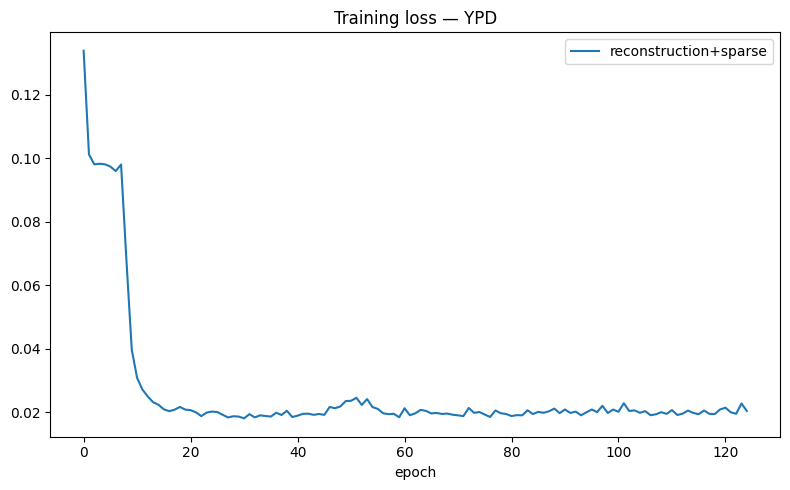

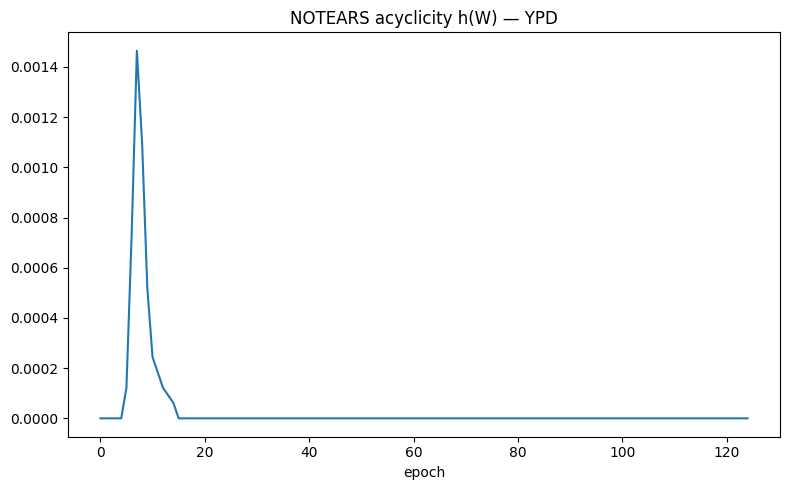


----------------------------------------------------------------------
TRAIN: YPDRapa | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0, rho=1, alpha=0
outer=2/5 h(W)=0, rho=1, alpha=0
outer=3/5 h(W)=0, rho=1, alpha=0
outer=4/5 h(W)=0, rho=1, alpha=0
outer=5/5 h(W)=0, rho=1, alpha=0
Training time: 5.09 min


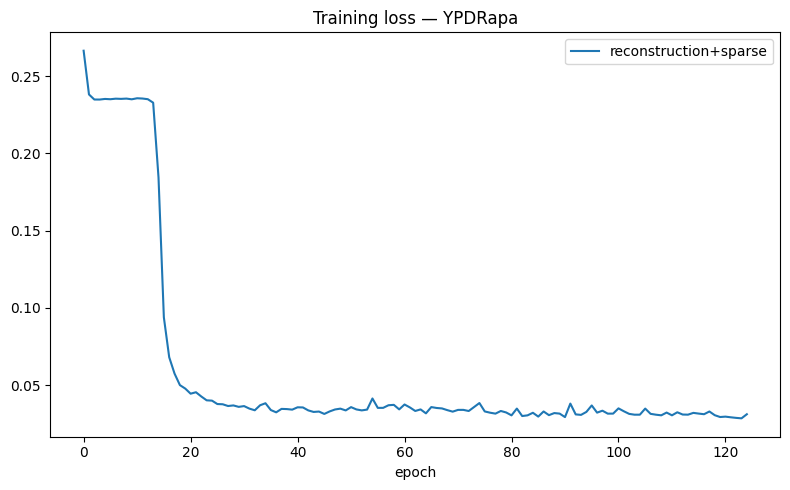

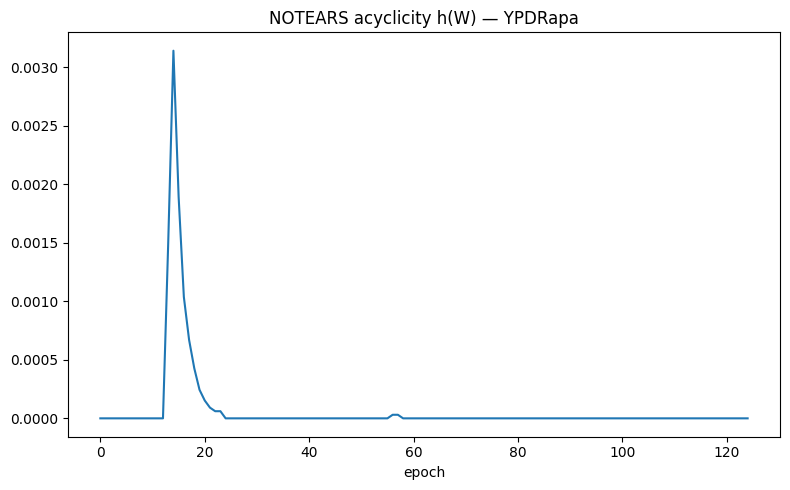


----------------------------------------------------------------------
TRAIN: YPDDiauxic | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.00726318, rho=1, alpha=0.00726
outer=2/5 h(W)=0.0010376, rho=1, alpha=0.0083
outer=3/5 h(W)=0.00259399, rho=1, alpha=0.0109
outer=4/5 h(W)=0.00640869, rho=1, alpha=0.0173
outer=5/5 h(W)=0.00543213, rho=1, alpha=0.0227
Training time: 1.49 min


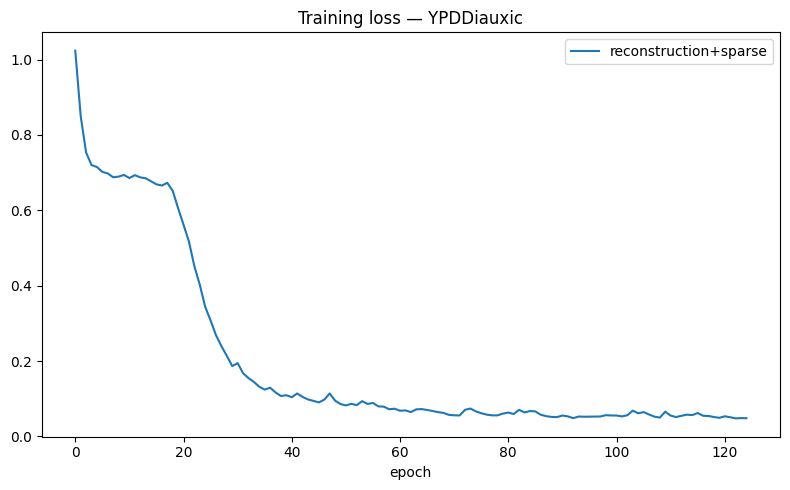

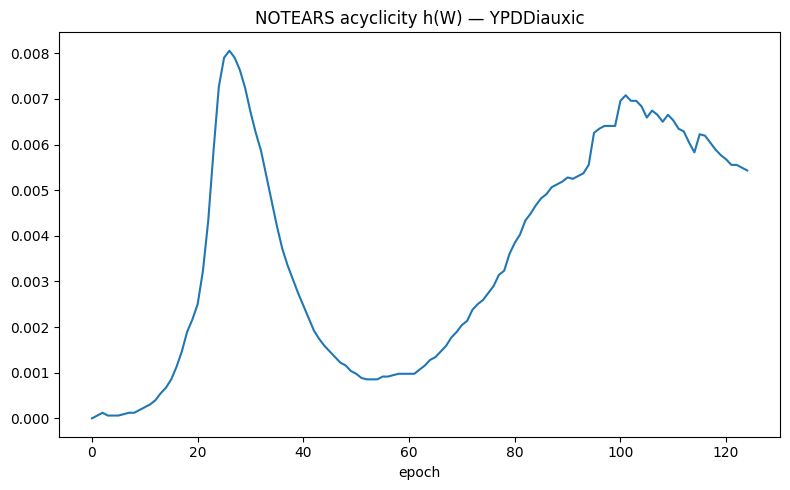


----------------------------------------------------------------------
TRAIN: CStarve | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.0158691, rho=1, alpha=0.0159
outer=2/5 h(W)=0.00640869, rho=1, alpha=0.0223
outer=3/5 h(W)=0.00274658, rho=1, alpha=0.025
outer=4/5 h(W)=0.00115967, rho=1, alpha=0.0262
outer=5/5 h(W)=0.000793457, rho=1, alpha=0.027
Training time: 1.55 min


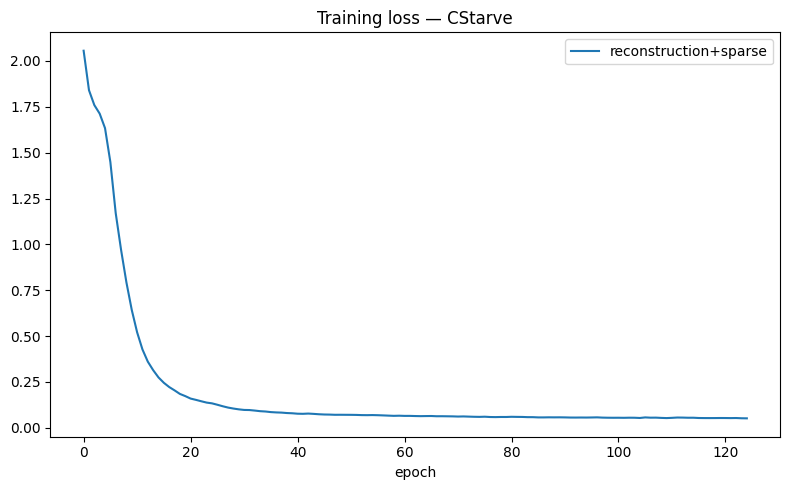

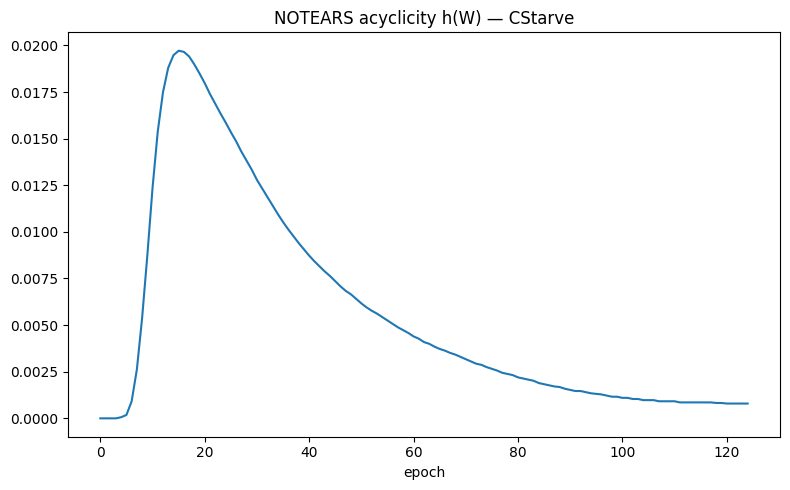

In [11]:
# ============================================================
# CELL 19 — Train all four GSE environments
# ============================================================
genes = np.array(adata_model.var_names.astype(str))
X_all = np.asarray(adata_model.X, dtype=np.float32)
PT_all = np.asarray(adata_model.obs["shared_pseudotime"], dtype=np.float32)
GENE_PT = np.asarray(gene_pt_series.loc[genes].values, dtype=np.float32)

models = {}
results = {}
timings = {}

for env in TARGET_ENVS:
    if (adata_model.obs["environment"] == env).sum() < 30:
        print(f"Skipping {env}: too few cells.")
        continue

    model, hist, elapsed = train_environment(
        env, X_all, PT_all, GENE_PT
    )
    models[env] = model
    timings[env] = elapsed

    # training plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(hist["reconstruction_plus_sparse"], label="reconstruction+sparse")
    ax.set_title(f"Training loss — {env}")
    ax.set_xlabel("epoch")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"training_loss_{env}.png", dpi=180)
    plt.show()

    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(hist["dag_h"])
    ax.set_title(f"NOTEARS acyclicity h(W) — {env}")
    ax.set_xlabel("epoch")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"dag_penalty_{env}.png", dpi=180)
    plt.show()



Computing Jacobian: YPD
Computing ablation: YPD


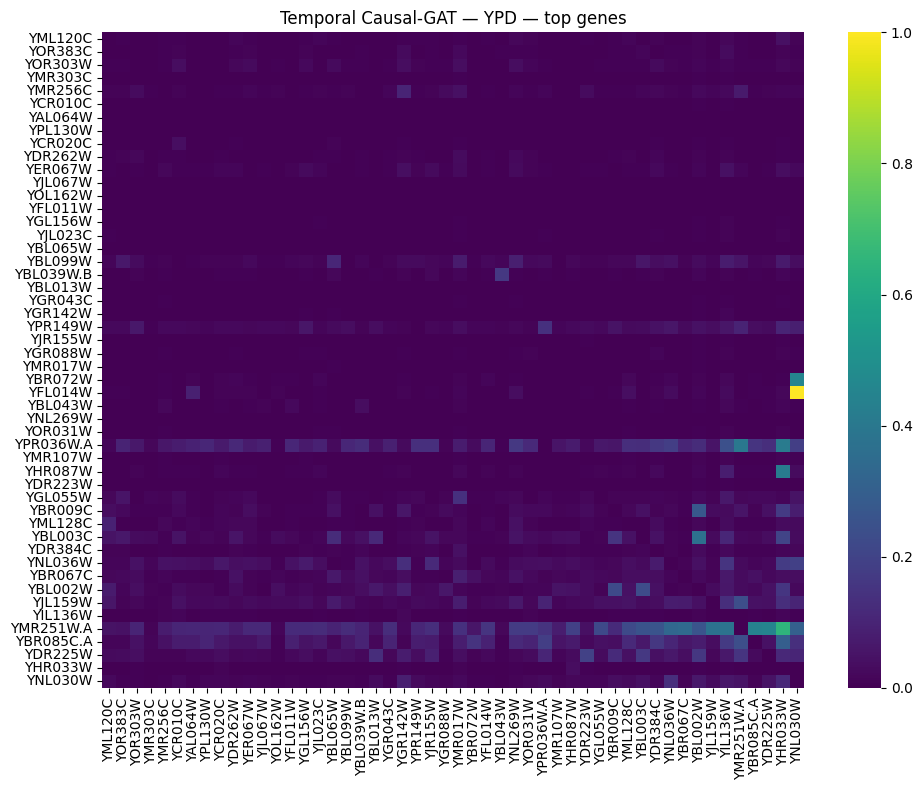

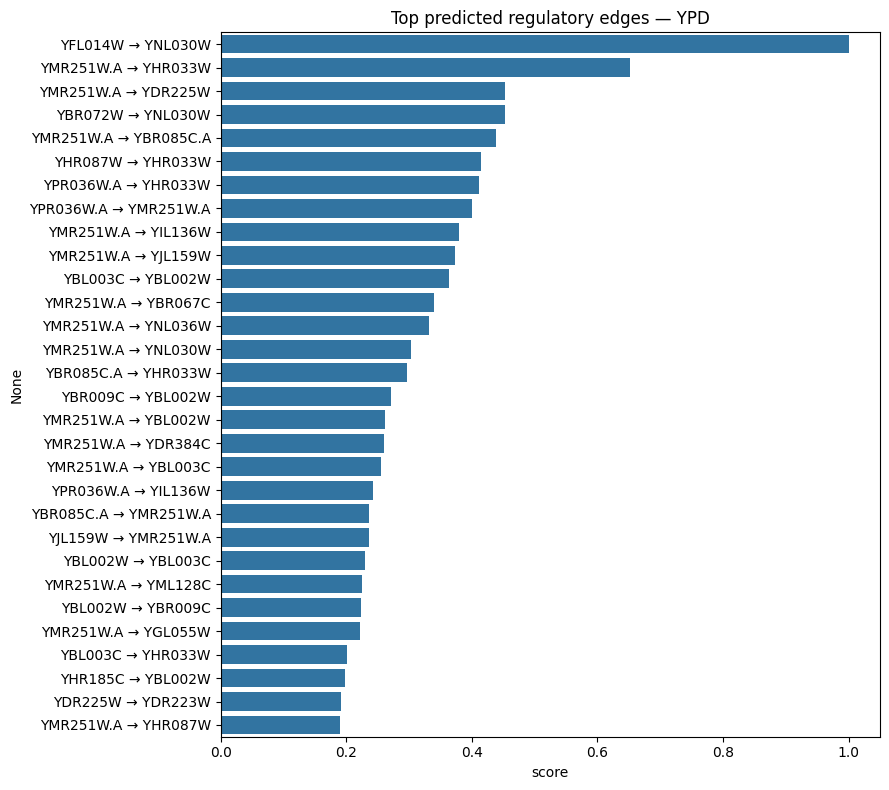


Computing Jacobian: YPDRapa
Computing ablation: YPDRapa


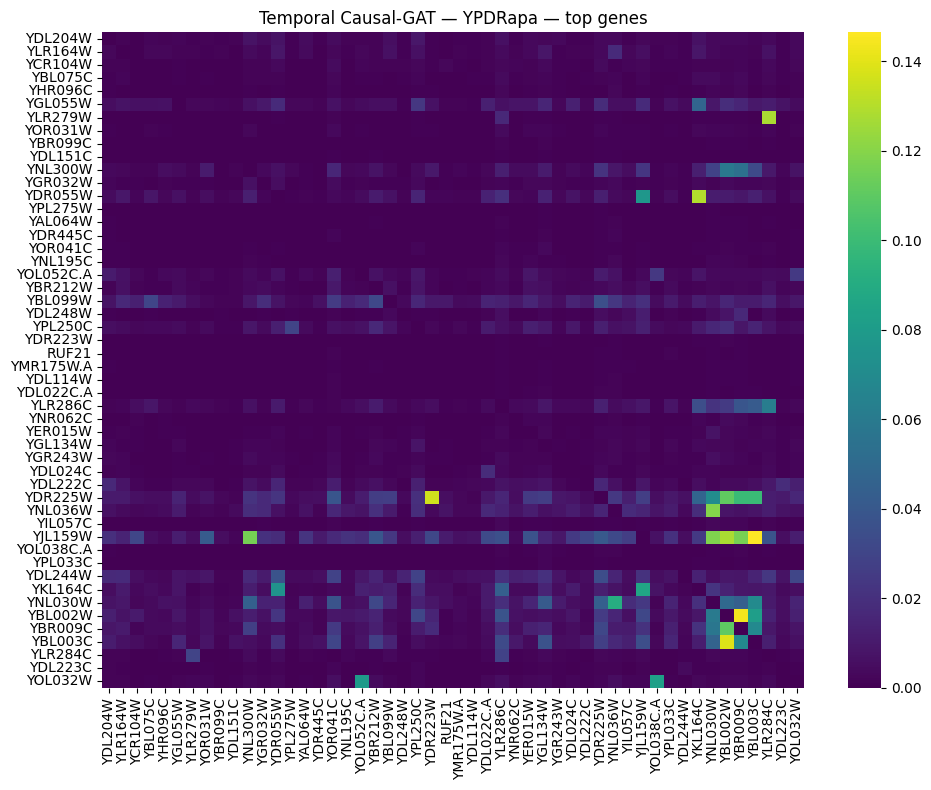

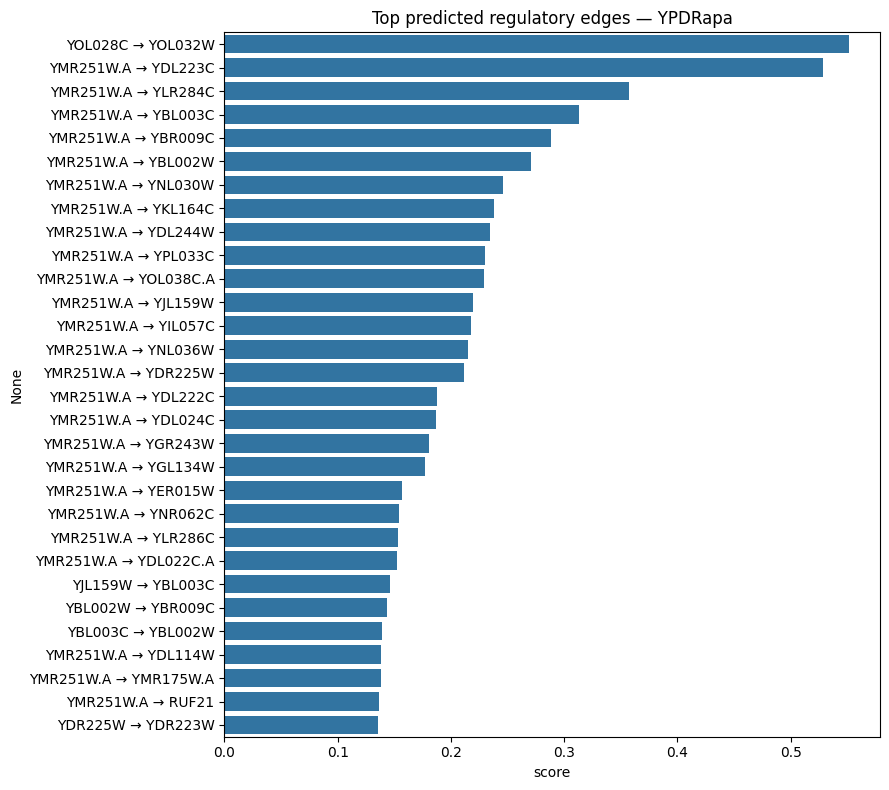


Computing Jacobian: YPDDiauxic
Computing ablation: YPDDiauxic


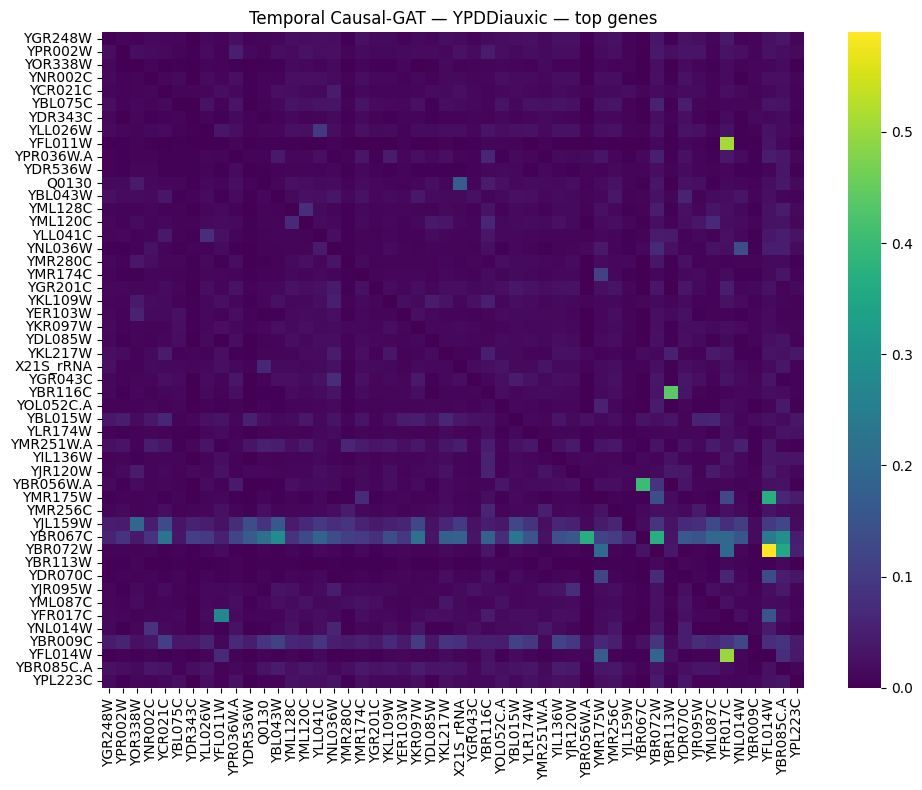

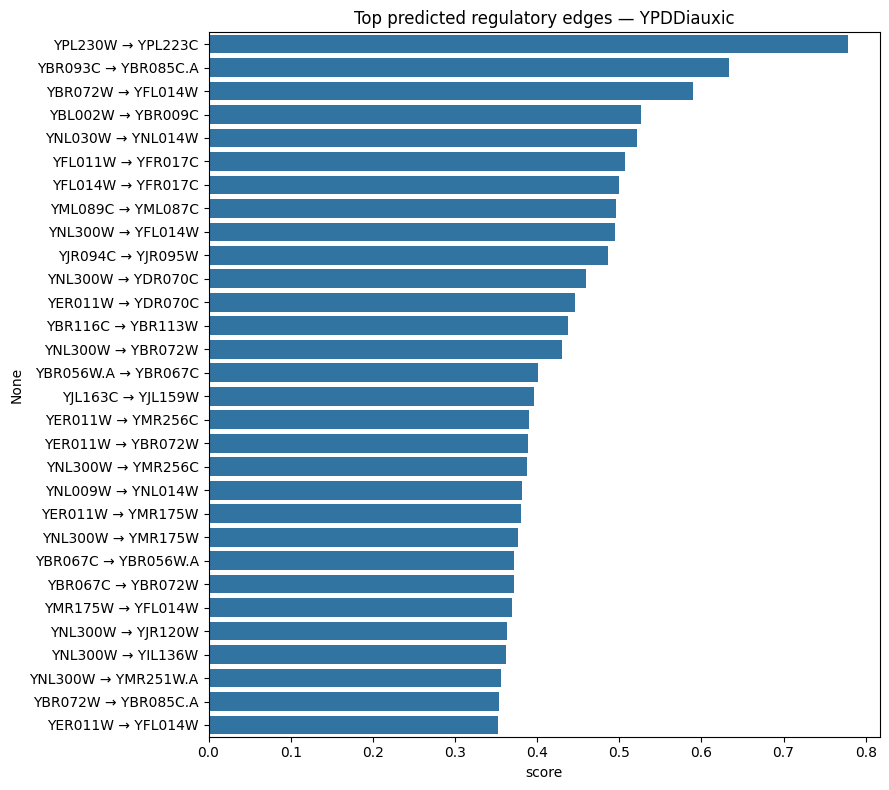


Computing Jacobian: CStarve
Computing ablation: CStarve


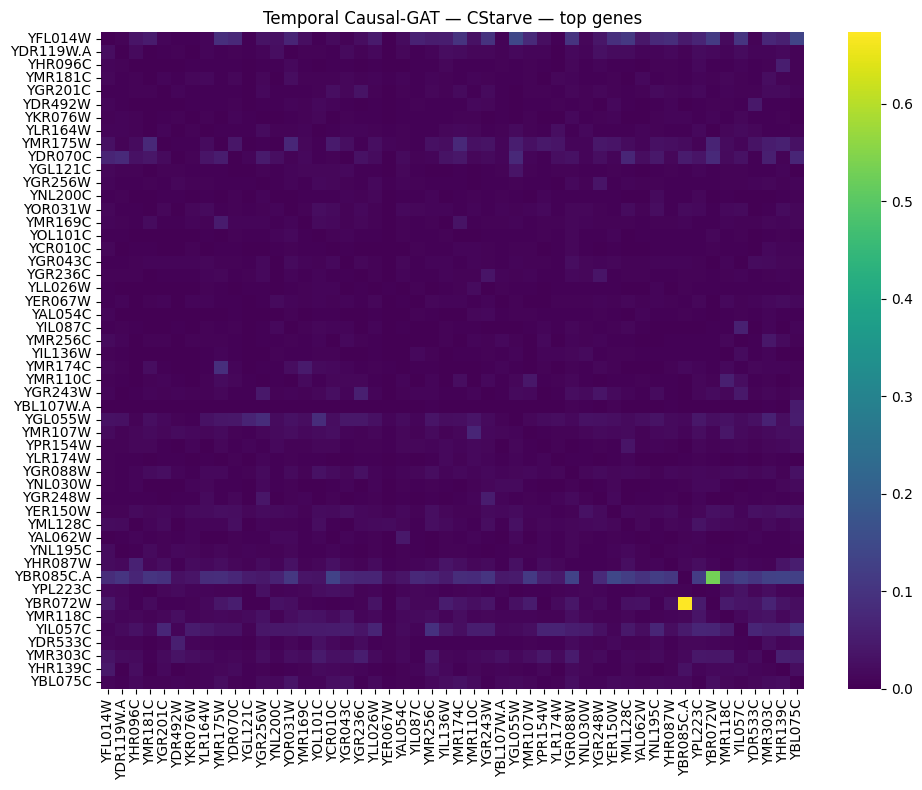

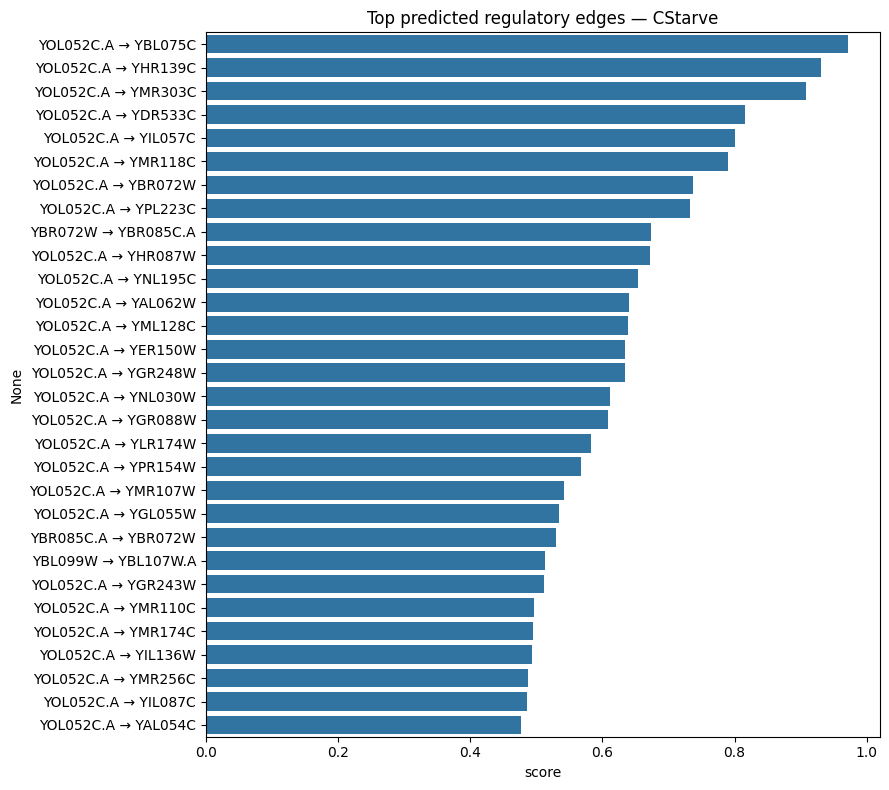

In [12]:
# ============================================================
# CELL 20 — Causal scores + baselines
# ============================================================
all_env_summary = []

for env, model in models.items():
    mask = adata_model.obs["environment"].values == env
    X_env = X_all[mask]
    pt_env = PT_all[mask]

    cond = one_hot_condition(env)
    temporal_prior = torch.tensor(GENE_PT, dtype=torch.float32, device=DEVICE)

    print("\nComputing Jacobian:", env)
    J = population_jacobian(
        model, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK
    )

    print("Computing ablation:", env)
    A = population_ablation_scores(
        model, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK
    )

    S = combine_causal_scores(
        J, A,
        grad_weight=GRAD_WEIGHT,
        ablation_weight=ABLATION_WEIGHT
    )

    corr_abs, corr_signed = correlation_network(X_env)

    np.save(OUT_DIR / f"jacobian_{env}.npy", J)
    np.save(OUT_DIR / f"ablation_{env}.npy", A)
    np.save(OUT_DIR / f"causal_score_{env}.npy", S)
    np.save(OUT_DIR / f"correlation_{env}.npy", corr_abs)

    # Structural W
    with torch.no_grad():
        dummy = torch.tensor(
            X_env[:min(32,len(X_env))],
            dtype=torch.float32,
            device=DEVICE
        )
        _, W, W_eff, attn = model(
            dummy,
            cond.unsqueeze(0),
            temporal_prior=temporal_prior,
            temporal_gamma=TEMPORAL_GAMMA
        )
        W_np = W.detach().cpu().numpy()
        Weff_np = W_eff.detach().cpu().numpy()

    np.save(OUT_DIR / f"W_struct_{env}.npy", W_np)
    np.save(OUT_DIR / f"W_effective_{env}.npy", Weff_np)

    # Edge tables
    matrix_to_edge_df(
        S, genes, signed_matrix=J
    ).to_csv(
        OUT_DIR / f"TemporalCausalGAT_edges_{env}.csv",
        index=False
    )

    matrix_to_edge_df(
        corr_abs, genes, signed_matrix=corr_signed
    ).to_csv(
        OUT_DIR / f"Correlation_edges_{env}.csv",
        index=False
    )

    # Heatmap: causal score
    topn = min(50, len(genes))
    top_idx = np.argsort(S.max(axis=0))[-topn:]
    H = S[np.ix_(top_idx, top_idx)]

    plt.figure(figsize=(10,8))
    sns.heatmap(
        H,
        xticklabels=genes[top_idx],
        yticklabels=genes[top_idx],
        cmap="viridis"
    )
    plt.title(f"Temporal Causal-GAT — {env} — top genes")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"GRN_heatmap_{env}.png", dpi=180)
    plt.show()

    # Top edges
    edge_df = matrix_to_edge_df(S, genes, signed_matrix=J).head(30)

    plt.figure(figsize=(9,8))
    sns.barplot(
        data=edge_df,
        x="score",
        y=edge_df["source"] + " → " + edge_df["target"]
    )
    plt.title(f"Top predicted regulatory edges — {env}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"top_edges_{env}.png", dpi=180)
    plt.show()

    # Save timing
    all_env_summary.append({
        "environment": env,
        "n_cells": int(X_env.shape[0]),
        "n_genes": int(X_env.shape[1]),
        "training_minutes": timings[env]
    })

pd.DataFrame(all_env_summary).to_csv(
    OUT_DIR / "environment_summary.csv", index=False
)


----------------------------------------------------------------------
TRAIN: YPD | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0, rho=1, alpha=0
outer=2/5 h(W)=0, rho=1, alpha=0
outer=3/5 h(W)=0, rho=1, alpha=0
outer=4/5 h(W)=0, rho=1, alpha=0
outer=5/5 h(W)=0, rho=1, alpha=0
Training time: 4.49 min


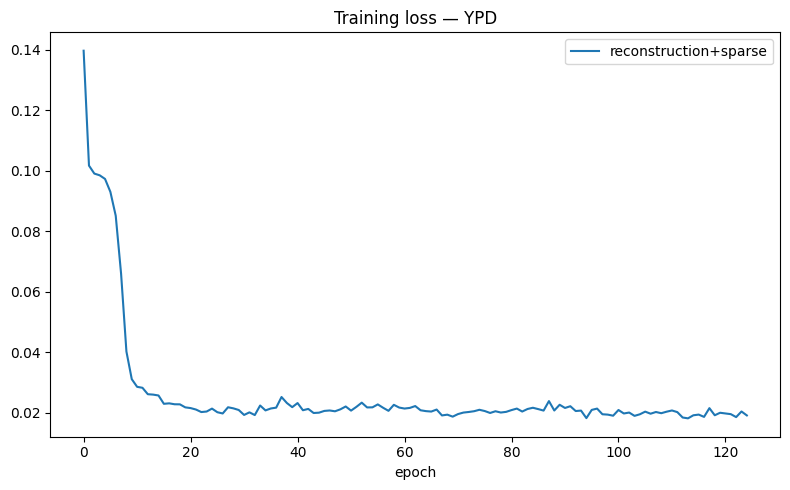

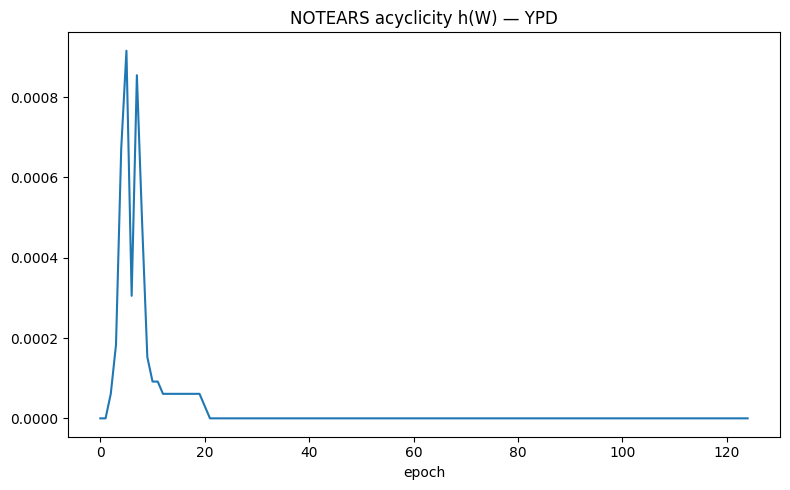


----------------------------------------------------------------------
TRAIN: YPDRapa | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.000793457, rho=1, alpha=0.000793
outer=2/5 h(W)=0.000244141, rho=1, alpha=0.00104
outer=3/5 h(W)=0.000488281, rho=1, alpha=0.00153
outer=4/5 h(W)=0.000396729, rho=1, alpha=0.00192
outer=5/5 h(W)=0.000366211, rho=1, alpha=0.00229
Training time: 5.10 min


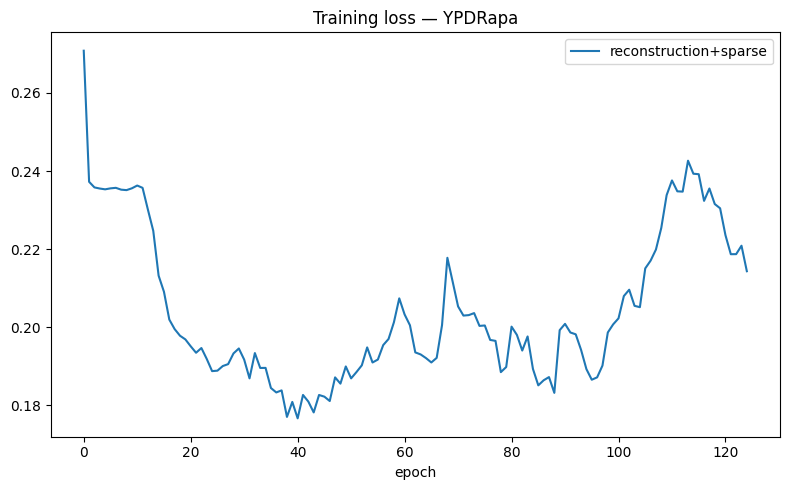

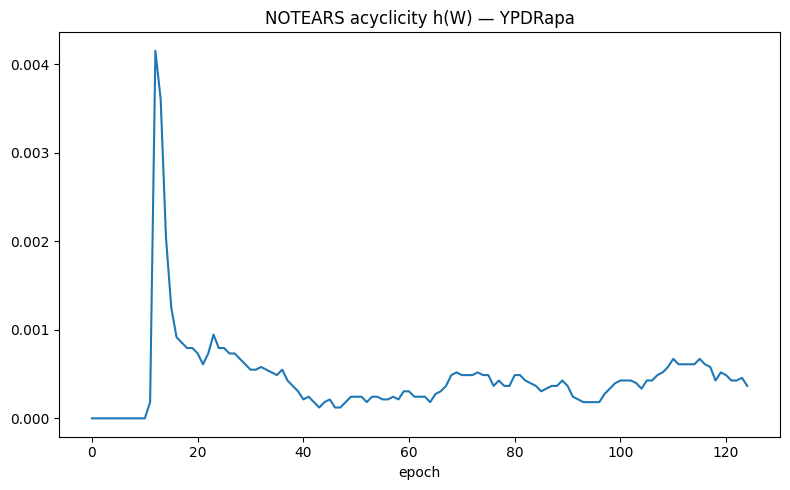


----------------------------------------------------------------------
TRAIN: YPDDiauxic | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.0100403, rho=1, alpha=0.01
outer=2/5 h(W)=0.0193176, rho=1, alpha=0.0294
outer=3/5 h(W)=0.00772095, rho=1, alpha=0.0371
outer=4/5 h(W)=0.00289917, rho=1, alpha=0.04
outer=5/5 h(W)=0.00106812, rho=1, alpha=0.041
Training time: 1.50 min


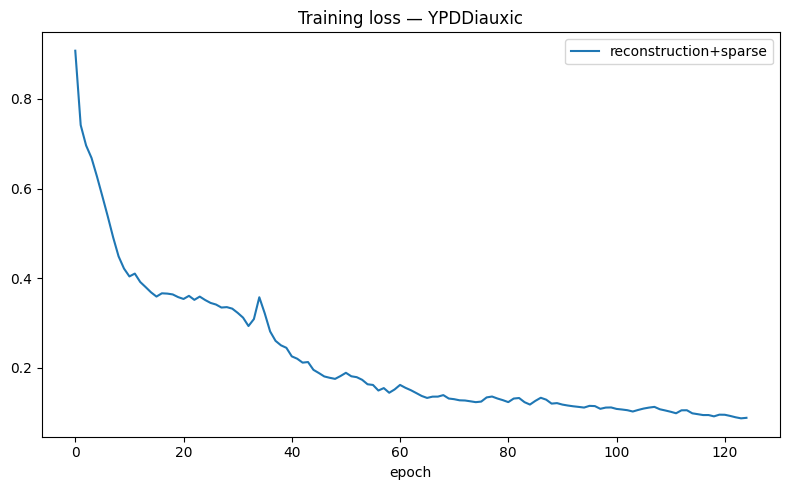

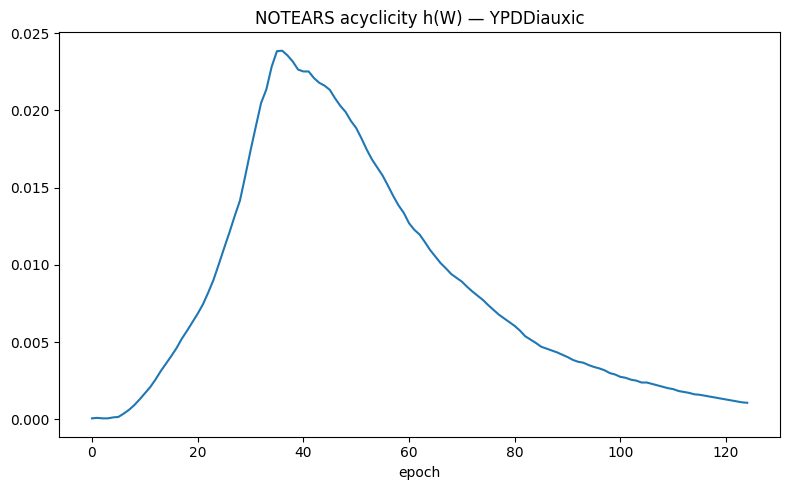


----------------------------------------------------------------------
TRAIN: CStarve | temporal_gamma=5.0 | use_condition=True
----------------------------------------------------------------------
outer=1/5 h(W)=0.0322876, rho=1, alpha=0.0323
outer=2/5 h(W)=0.0484619, rho=1, alpha=0.0807
outer=3/5 h(W)=0.0353088, rho=1, alpha=0.116
outer=4/5 h(W)=0.020813, rho=1, alpha=0.137
outer=5/5 h(W)=0.0147705, rho=1, alpha=0.152
Training time: 1.55 min


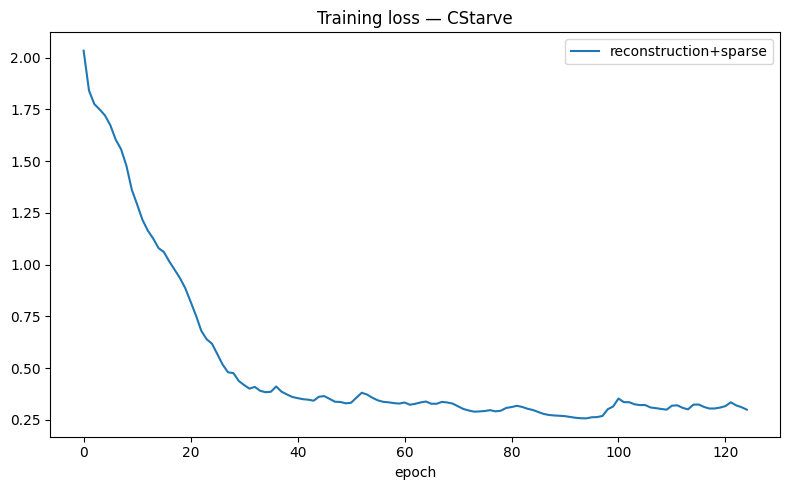

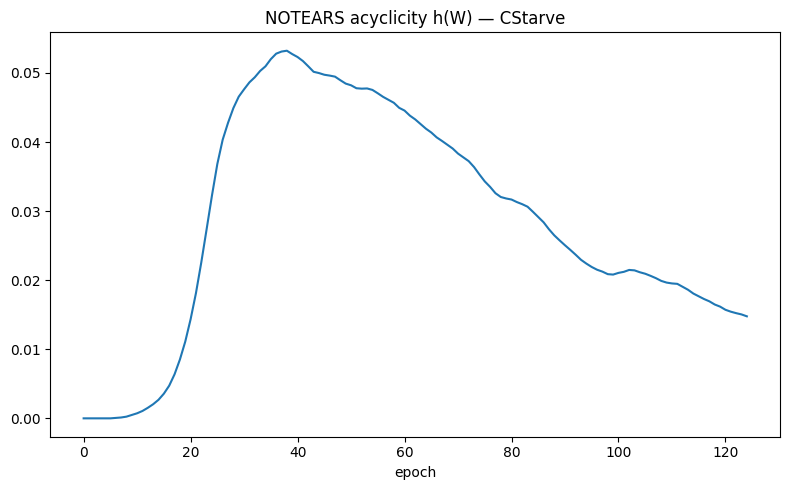


Computing Jacobian: YPD


RuntimeError: cudnn RNN backward can only be called in training mode

In [6]:
# ============================================================
# CELL 21 — YEASTRACT evaluation, if supplied
# ============================================================
gold = load_gold(YEASTRACT_PATH)

if gold is None:
    print(
        "\nYEASTRACT gold standard not found at:",
        YEASTRACT_PATH,
        "\nPredictions were saved; evaluation is skipped."
    )
else:
    print("\nYEASTRACT gold edges:", len(gold))

    eval_rows = []
    roc_data = {}
    pr_data = {}

    for env, model in models.items():
        S = np.load(OUT_DIR / f"causal_score_{env}.npy")
        C = np.load(OUT_DIR / f"correlation_{env}.npy")

        # K = number of gold edges that are inside the candidate gene set
        gold_in = gold[
            gold["source"].astype(str).isin(set(genes)) &
            gold["target"].astype(str).isin(set(genes))
        ]
        K = max(len(gold_in), 1)

        r1, curves1 = benchmark_score_matrix(
            S, genes, gold, top_k=K, name="Temporal Causal-GAT"
        )
        r2, curves2 = benchmark_score_matrix(
            C, genes, gold, top_k=K, name="Correlation"
        )

        r1["environment"] = env
        r2["environment"] = env
        eval_rows.extend([r1,r2])

        y1,s1 = curves1
        y2,s2 = curves2

        if r1["AUROC"] == r1["AUROC"]:
            fpr,tpr,_ = roc_curve(y1,s1)
            roc_data[f"{env} — Causal-GAT"] = (fpr,tpr)
            p,r,_ = precision_recall_curve(y1,s1)
            pr_data[f"{env} — Causal-GAT"] = (r,p)

        if r2["AUROC"] == r2["AUROC"]:
            fpr,tpr,_ = roc_curve(y2,s2)
            roc_data[f"{env} — Correlation"] = (fpr,tpr)
            p,r,_ = precision_recall_curve(y2,s2)
            pr_data[f"{env} — Correlation"] = (r,p)

        shd = directed_shd_at_k(S, genes, gold, K)
        eval_rows[-2]["SHD@K"] = shd
        eval_rows[-1]["SHD@K"] = directed_shd_at_k(C, genes, gold, K)

    eval_df = pd.DataFrame(eval_rows)
    eval_df.to_csv(OUT_DIR / "YEASTRACT_evaluation.csv", index=False)
    print(eval_df)

    # AUROC
    plt.figure(figsize=(9,5))
    sns.barplot(data=eval_df, x="environment", y="AUROC", hue="model")
    plt.ylim(0,1)
    plt.title("AUROC — YEASTRACT")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "YEASTRACT_AUROC.png", dpi=180)
    plt.show()

    # AUPRC
    plt.figure(figsize=(9,5))
    sns.barplot(data=eval_df, x="environment", y="AUPRC", hue="model")
    plt.ylim(0,1)
    plt.title("AUPRC — YEASTRACT")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "YEASTRACT_AUPRC.png", dpi=180)
    plt.show()

    # ROC curves
    plt.figure(figsize=(9,7))
    for label,(fpr,tpr) in roc_data.items():
        plt.plot(fpr,tpr,label=label)
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves — YEASTRACT")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "YEASTRACT_ROC_curves.png", dpi=180)
    plt.show()

    # PR curves
    plt.figure(figsize=(9,7))
    for label,(rec,prec) in pr_data.items():
        plt.plot(rec,prec,label=label)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves — YEASTRACT")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "YEASTRACT_PR_curves.png", dpi=180)
    plt.show()

# ============================================================
# CELL 22 — GENIE3 on exactly the same GSE gene set
# ============================================================
genie3_scores = {}

if RUN_GENIE3:
    print("\n" + "="*70)
    print("STEP 3 — GENIE3 BASELINE")
    print("="*70)

    for env in models.keys():
        mask = adata_model.obs["environment"].values == env
        X_env = X_all[mask]

        print(f"\nRunning GENIE3 — {env}")
        t0 = time.time()

        try:
            G3 = run_genie3_baseline(X_env, genes)
            genie3_scores[env] = G3
            np.save(OUT_DIR / f"GENIE3_{env}.npy", G3)

            matrix_to_edge_df(G3, genes).to_csv(
                OUT_DIR / f"GENIE3_edges_{env}.csv",
                index=False
            )

            print(f"GENIE3 completed in {(time.time()-t0)/60:.2f} min")

        except Exception as e:
            print("GENIE3 failed:", repr(e))
            print(
                "The rest of the pipeline remains available, but "
                "GENIE3 cannot be reported as a completed baseline for this run."
            )

# Evaluate GENIE3 if gold is present
if gold is not None and len(genie3_scores):
    g3_rows = []

    for env, G3 in genie3_scores.items():
        gold_in = gold[
            gold["source"].astype(str).isin(set(genes)) &
            gold["target"].astype(str).isin(set(genes))
        ]
        K = max(len(gold_in),1)

        r, _ = benchmark_score_matrix(
            G3, genes, gold, top_k=K, name="GENIE3"
        )
        r["environment"] = env
        r["SHD@K"] = directed_shd_at_k(G3, genes, gold, K)
        g3_rows.append(r)

    g3_df = pd.DataFrame(g3_rows)
    g3_df.to_csv(OUT_DIR / "GENIE3_YEASTRACT_evaluation.csv", index=False)
    print("\nGENIE3 evaluation:")
    print(g3_df)

# ============================================================
# CELL 23 — Final GSE model comparison
# ============================================================
if gold is not None:
    comparison_rows = []

    for env in models.keys():
        gold_in = gold[
            gold["source"].astype(str).isin(set(genes)) &
            gold["target"].astype(str).isin(set(genes))
        ]
        K = max(len(gold_in),1)

        S = np.load(OUT_DIR / f"causal_score_{env}.npy")
        C = np.load(OUT_DIR / f"correlation_{env}.npy")

        for name, M in [
            ("Temporal Causal-GAT", S),
            ("Correlation", C)
        ]:
            r,_ = benchmark_score_matrix(
                M, genes, gold, top_k=K, name=name
            )
            r["environment"] = env
            r["SHD@K"] = directed_shd_at_k(M, genes, gold, K)
            comparison_rows.append(r)

        if env in genie3_scores:
            r,_ = benchmark_score_matrix(
                genie3_scores[env], genes, gold, top_k=K, name="GENIE3"
            )
            r["environment"] = env
            r["SHD@K"] = directed_shd_at_k(
                genie3_scores[env], genes, gold, K
            )
            comparison_rows.append(r)

    comparison = pd.DataFrame(comparison_rows)
    comparison.to_csv(
        OUT_DIR / "FINAL_GSE125162_MODEL_COMPARISON.csv",
        index=False
    )

    print("\nFINAL GSE125162 comparison:")
    print(comparison)

    for metric in ["AUROC","AUPRC"]:
        plt.figure(figsize=(10,5))
        sns.barplot(
            data=comparison,
            x="environment",
            y=metric,
            hue="model"
        )
        plt.ylim(0,1)
        plt.title(f"{metric} — GSE125162 / YEASTRACT")
        plt.tight_layout()
        plt.savefig(
            OUT_DIR / f"FINAL_{metric}_comparison.png",
            dpi=180
        )
        plt.show()

# ============================================================
# CELL 24 — DREAM5 dedicated loader
# ============================================================
print("\n" + "="*70)
print("STEP 4 — DREAM5")
print("="*70)

def load_dream5_expression(path):
    path = Path(path)
    if not path.exists():
        return None

    df = pd.read_csv(path, sep="\t", index_col=0)

    # Auto-orient to samples x genes if genes appear in index.
    if np.mean([looks_like_gene_id(x) for x in df.index[:min(1000,len(df.index))]]) > \
       np.mean([looks_like_gene_id(x) for x in df.columns[:min(1000,len(df.columns))]]):
        df = df.T

    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)

    return df

def load_dream5_gold(path):
    path = Path(path)
    if not path.exists():
        return None

    # DREAM5 gold files commonly have whitespace-delimited source/target.
    try:
        g = pd.read_csv(path, sep="\t", header=None)
        if g.shape[1] >= 2:
            g = g.iloc[:,:2]
            g.columns = ["source","target"]
            g["source"] = g["source"].astype(str)
            g["target"] = g["target"].astype(str)
            return g.drop_duplicates()
    except Exception:
        pass

    g = pd.read_csv(path)
    cols = [c.lower() for c in g.columns]
    src = next((g.columns[i] for i,c in enumerate(cols)
                if c in ["source","tf","regulator","gene1","from"]), None)
    tgt = next((g.columns[i] for i,c in enumerate(cols)
                if c in ["target","gene","gene2","to"]), None)
    if src and tgt:
        return g[[src,tgt]].rename(columns={src:"source",tgt:"target"}).drop_duplicates()

    raise ValueError(f"Could not parse DREAM5 gold file: {path}")

def load_tf_list(path):
    path = Path(path)
    if not path.exists():
        return None
    vals = []
    for line in path.read_text().splitlines():
        s = line.strip()
        if s and not s.startswith("#"):
            vals.append(s.split()[0])
    return sorted(set(vals))

dream_expr = load_dream5_expression(DREAM5_EXPRESSION_PATH)
dream_gold = load_dream5_gold(DREAM5_GOLD_PATH)
dream_tfs = load_tf_list(DREAM5_TF_PATH)

if dream_expr is None or dream_gold is None or dream_tfs is None:
    print(
        "\nDREAM5 files were not found in /content.\n"
        "Expected:\n",
        DREAM5_EXPRESSION_PATH,
        DREAM5_GOLD_PATH,
        DREAM5_TF_PATH,
        "\n"
        "No DREAM5 score is fabricated; evaluation will be skipped until "
        "the actual benchmark files are present."
    )
else:
    print("DREAM5 expression:", dream_expr.shape)
    print("DREAM5 gold:", dream_gold.shape)
    print("DREAM5 TFs:", len(dream_tfs))

    dream_genes = np.array(dream_expr.columns.astype(str))
    tf_set = set(dream_tfs) & set(dream_genes)

    # ---- Correlation benchmark on DREAM5 ----
    D = np.asarray(dream_expr.values, dtype=np.float32)
    corr_dream, _ = correlation_network(D)

    # Only TF -> target candidate space.
    dream_gold_in = dream_gold[
        dream_gold["source"].astype(str).isin(tf_set) &
        dream_gold["target"].astype(str).isin(set(dream_genes))
    ].copy()

    K = max(len(dream_gold_in),1)

    r_dream, curves_dream = benchmark_score_matrix(
        corr_dream,
        dream_genes,
        dream_gold,
        source_restriction=tf_set,
        top_k=K,
        name="Correlation"
    )

    r_dream["benchmark"] = "DREAM5"
    r_dream["SHD@K"] = directed_shd_at_k(
        corr_dream, dream_genes, dream_gold_in, K
    )

    dream_eval = pd.DataFrame([r_dream])
    dream_eval.to_csv(
        OUT_DIR / "DREAM5_correlation_evaluation.csv",
        index=False
    )

    print("\nDREAM5 Correlation result:")
    print(dream_eval)

    # ROC / PR
    y,s = curves_dream
    if r_dream["AUROC"] == r_dream["AUROC"]:
        fpr,tpr,_ = roc_curve(y,s)
        plt.figure(figsize=(7,6))
        plt.plot(fpr,tpr,label=f"Correlation AUROC={r_dream['AUROC']:.4f}")
        plt.plot([0,1],[0,1],"--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("DREAM5 ROC — TF → target candidate space")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT_DIR / "DREAM5_ROC.png", dpi=180)
        plt.show()

        precision, recall, _ = precision_recall_curve(y,s)
        plt.figure(figsize=(7,6))
        plt.plot(recall,precision,label=f"Correlation AUPRC={r_dream['AUPRC']:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("DREAM5 Precision-Recall")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT_DIR / "DREAM5_PR.png", dpi=180)
        plt.show()

    # ========================================================
    # Optional reduced DREAM5 Causal-GAT
    # ========================================================
    if RUN_REDUCED_DREAM5_CAUSAL_GAT:
        print(
            "\nReduced DREAM5 Causal-GAT is optional and is NOT the official "
            "full DREAM5 benchmark."
        )

        # Select TFs plus genes appearing in gold, then limit.
        candidate_genes = list(
            dict.fromkeys(
                list(tf_set) +
                dream_gold_in["target"].astype(str).tolist()
            )
        )
        candidate_genes = [g for g in candidate_genes if g in dream_expr.columns]
        candidate_genes = candidate_genes[:DREAM5_REDUCED_GENES]

        if len(candidate_genes) >= 50:
            Xd = dream_expr[candidate_genes].values.astype(np.float32)

            # No pseudotime on DREAM5.
            # We use a zero temporal prior and disable temporal effect.
            model_d = TemporalCausalGAT(
                G=len(candidate_genes),
                hidden=HIDDEN,
                cond_dim=COND_DIM,
                rank=LOW_RANK
            ).to(DEVICE)

            # Minimal non-temporal fit for benchmark sanity check.
            opt = torch.optim.Adam(
                model_d.parameters(),
                lr=LR,
                weight_decay=WEIGHT_DECAY
            )
            Xt = torch.tensor(Xd, dtype=torch.float32)
            cd = torch.zeros(COND_DIM, device=DEVICE)
            tp = torch.zeros(len(candidate_genes), device=DEVICE)

            for ep in range(30):
                for idx in make_batches(len(Xd), min(INFER_CELL_CHUNK,len(Xd))):
                    xb = Xt[idx].to(DEVICE)
                    opt.zero_grad()
                    yhat,W,We,attn = model_d(
                        xb, cd.unsqueeze(0),
                        temporal_prior=tp,
                        temporal_gamma=0.0
                    )
                    loss = ((yhat-xb)**2).mean() + LAMBDA_SPARSE*torch.abs(W).sum()
                    loss.backward()
                    opt.step()

            Jd = population_jacobian(
                model_d, Xd, cd, tp, chunk=INFER_CELL_CHUNK,
                temporal_gamma=0.0  # 🟢 هماهنگ با temporal_gamma=0.0 که در training همین model_d استفاده شد
            )
            Ad = population_ablation_scores(
                model_d, Xd, cd, tp, chunk=INFER_CELL_CHUNK,
                temporal_gamma=0.0
            )
            Sd = combine_causal_scores(Jd,Ad)

            tf_restricted = set(dream_tfs) & set(candidate_genes)
            gold_reduced = dream_gold[
                dream_gold["source"].astype(str).isin(tf_restricted) &
                dream_gold["target"].astype(str).isin(set(candidate_genes))
            ]

            Kd = max(len(gold_reduced),1)

            rd,_ = benchmark_score_matrix(
                Sd,
                np.array(candidate_genes),
                gold_reduced,
                source_restriction=tf_restricted,
                top_k=Kd,
                name="Reduced Causal-GAT"
            )
            rd["benchmark"] = "DREAM5_reduced"
            rd["n_genes"] = len(candidate_genes)

            pd.DataFrame([rd]).to_csv(
                OUT_DIR / "DREAM5_reduced_CausalGAT_evaluation.csv",
                index=False
            )
            print(rd)

# ============================================================
# CELL 25 — Save AnnData
# ============================================================
adata_model.obs["shared_pseudotime"] = shared_pt
adata_model.write(OUT_DIR / "GSE125162_processed_model.h5ad")

# Save gene list
pd.DataFrame({"gene": genes}).to_csv(
    OUT_DIR / "final_gene_set.csv", index=False
)

# Save run configuration
config = {
    "seed": SEED,
    "target_environments": TARGET_ENVS,
    "n_hvg": N_HVG,
    "hidden": HIDDEN,
    "cond_dim": COND_DIM,
    "low_rank": LOW_RANK,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "lambda_sparse": LAMBDA_SPARSE,
    "temporal_gamma": TEMPORAL_GAMMA,
    "dag_outer_steps": DAG_OUTER_STEPS,
    "epochs_per_dag_step": EPOCHS_PER_DAG_STEP,
    "grad_weight": GRAD_WEIGHT,
    "ablation_weight": ABLATION_WEIGHT,
    "device": str(DEVICE),
}
pd.Series(config).to_csv(OUT_DIR / "run_config.csv")

# ============================================================
# CELL 26 — Final summary
# ============================================================
print("\n" + "="*70)
print("PIPELINE FINISHED")
print("="*70)
print("Results directory:", OUT_DIR)
print("\nMain outputs:")
print(" - GSE125162_processed_model.h5ad")
print(" - TemporalCausalGAT_edges_<ENV>.csv")
print(" - Correlation_edges_<ENV>.csv")
print(" - GENIE3_edges_<ENV>.csv (if GENIE3 succeeded)")
print(" - YEASTRACT_evaluation.csv (if YEASTRACT file supplied)")
print(" - FINAL_GSE125162_MODEL_COMPARISON.csv")
print(" - DREAM5_correlation_evaluation.csv (if DREAM5 files supplied)")
print(" - QC / UMAP / pseudotime / ROC / PR / comparison figures")
print("\nIMPORTANT FOR THESIS REPORTING:")
print("1) Report candidate gene coverage / gold-edge coverage.")
print("2) Report AUROC + AUPRC, not AUROC alone.")
print("3) Report SHD@K explicitly as a fixed-budget metric.")
print("4) GENIE3 and Correlation must use the same GSE gene set.")
print("5) DREAM5 uses TF -> target candidate space and no scRNA pseudotime.")
print("6) State that DPT is relative pseudotime and ablation is in-silico.")
print("7) Do not claim observational scRNA-seq alone proves causal identification.")

# ============================================================
# CELL 27 — Candidate / gold-edge coverage report
# ============================================================
# 🟢 (بازبینی هشتم) این سلول دقیقاً همان چیزی را که CELL 26 از قبل
# در «IMPORTANT FOR THESIS REPORTING» به‌عنوان مورد ۱ خواسته بود
# ("Report candidate gene coverage / gold-edge coverage") به‌صورت
# عددی و ذخیره‌شده در فایل تولید می‌کند؛ قبلاً این فقط یک یادآوری
# متنی بود، نه یک خروجی واقعی.
coverage_rows = []

if gold is not None:
    gold_genes = set(gold["source"].astype(str)) | set(gold["target"].astype(str))
    model_genes_set = set(genes)
    gold_in_model = gold_genes & model_genes_set
    gold_edges_covered = gold[
        gold["source"].astype(str).isin(model_genes_set) &
        gold["target"].astype(str).isin(model_genes_set)
    ]
    coverage_rows.append({
        "benchmark": "YEASTRACT",
        "n_model_genes": len(genes),
        "n_gold_genes_total": len(gold_genes),
        "n_gold_genes_in_model": len(gold_in_model),
        "gold_gene_coverage_fraction": len(gold_in_model) / max(len(gold_genes), 1),
        "n_gold_edges_total": len(gold),
        "n_gold_edges_covered": len(gold_edges_covered),
        "gold_edge_coverage_fraction": len(gold_edges_covered) / max(len(gold), 1),
    })
else:
    print("YEASTRACT gold-standard بارگذاری نشده — گزارش coverage برای آن رد می‌شود "
          "(هیچ عددی جعل نمی‌شود).")

if "dream_genes" in dir() and "dream_gold" in dir() and "tf_set" in dir():
    dream_gold_genes = set(dream_gold["source"].astype(str)) | set(dream_gold["target"].astype(str))
    dream_model_genes_set = set(dream_genes)
    dream_gold_in_model = dream_gold_genes & dream_model_genes_set
    dream_gold_edges_covered = dream_gold[
        dream_gold["source"].astype(str).isin(dream_model_genes_set) &
        dream_gold["target"].astype(str).isin(dream_model_genes_set)
    ]
    coverage_rows.append({
        "benchmark": "DREAM5",
        "n_model_genes": len(dream_genes),
        "n_gold_genes_total": len(dream_gold_genes),
        "n_gold_genes_in_model": len(dream_gold_in_model),
        "gold_gene_coverage_fraction": len(dream_gold_in_model) / max(len(dream_gold_genes), 1),
        "n_gold_edges_total": len(dream_gold),
        "n_gold_edges_covered": len(dream_gold_edges_covered),
        "gold_edge_coverage_fraction": len(dream_gold_edges_covered) / max(len(dream_gold), 1),
        "n_tfs_in_candidate_space": len(tf_set),
    })
else:
    print("فایل‌های DREAM5 بارگذاری نشده‌اند — گزارش coverage برای آن رد می‌شود "
          "(هیچ عددی جعل نمی‌شود).")

if coverage_rows:
    coverage_df = pd.DataFrame(coverage_rows)
    coverage_df.to_csv(OUT_DIR / "candidate_gold_coverage.csv", index=False)
    print("\nCandidate / gold-edge coverage:")
    print(coverage_df.to_string(index=False))
    print(
        "\nنکته برای فصل نتایج: این اعداد را همراه AUROC/AUPRC گزارش کن — "
        "یک AUROC بالا روی یک فضای کاندید با پوشش کم از گفتن (gold edges) "
        "به‌تنهایی قابل‌اتکا نیست."
    )
else:
    print("هیچ‌کدام از YEASTRACT/DREAM5 بارگذاری نشدند — گزارش coverage خالی است.")


# ============================================================
# CELL 28 — Multi-seed stability (mean ± SD)
# ============================================================
# 🟢 (بازبینی هشتم) اجرای اصلی (CELL 19-21) فقط با یک SEED انجام
# می‌شود. برای گزارش پایداری نتیجه نسبت به seed — که در فصل نتایج
# پایان‌نامه معمولاً به‌صورت mean ± SD گزارش می‌شود — اینجا
# N_EXTRA_SEEDS اجرای اضافی روی seedهای دیگر انجام می‌شود؛ علاوه بر
# اجرای اصلی، نه به‌جای آن. نتیجه seed اصلی (SEED) از فایل‌های
# causal_score_{env}.npy که در CELL 20 قبلاً ذخیره شده مجدداً
# محاسبه نمی‌شود (صرفه‌جویی زمان اجرا).
#
# ⚠️ هزینه محاسباتی: هر seed اضافی یعنی آموزش از صفر برای هر محیط در
# MULTISEED_ENVS. پیش‌فرض همه محیط‌های موفق را پوشش می‌دهد؛ اگر زمان
# Colab محدود است، MULTISEED_ENVS را به یک یا دو محیط نماینده محدود
# کن یا N_EXTRA_SEEDS را کاهش بده (حتی N_EXTRA_SEEDS=0 قابل قبول
# است — یعنی این بخش را رد کن و فقط به نتیجه تک‌seed اصلی اکتفا کن؛
# این باید صریحاً در فصل محدودیت‌ها ذکر شود).

N_EXTRA_SEEDS = 2  # به‌همراه seed اصلی SEED، مجموعاً 3 اجرا
EXTRA_SEEDS = [SEED + 1000 + i for i in range(N_EXTRA_SEEDS)]
MULTISEED_ENVS = list(models.keys())

if gold is None:
    print("YEASTRACT gold-standard در دسترس نیست — گزارش پایداری چندseedی "
          "بدون معیار ارزیابی بی‌معنی است؛ این سلول رد می‌شود.")
elif N_EXTRA_SEEDS <= 0 or not MULTISEED_ENVS:
    print("N_EXTRA_SEEDS=0 یا هیچ محیط موفقی وجود ندارد — گزارش چندseedی "
          "رد می‌شود؛ فقط نتیجه تک‌seed اصلی معتبر است (در فصل محدودیت‌ها "
          "ذکر شود).")
else:
    multiseed_rows = []
    gold_in_ms = gold[
        gold["source"].astype(str).isin(set(genes)) &
        gold["target"].astype(str).isin(set(genes))
    ]
    K_ms = max(len(gold_in_ms), 1)

    # --- seed اصلی: از نتایج از پیش محاسبه‌شده CELL 19-21 ---
    for env in MULTISEED_ENVS:
        S_main = np.load(OUT_DIR / f"causal_score_{env}.npy")
        r_main, _ = benchmark_score_matrix(
            S_main, genes, gold, top_k=K_ms, name="Temporal Causal-GAT")
        r_main["environment"] = env
        r_main["seed"] = SEED
        r_main["SHD@K"] = directed_shd_at_k(S_main, genes, gold, K_ms)
        multiseed_rows.append(r_main)

    # --- seedهای اضافی: آموزش کامل از صفر ---
    for extra_seed in EXTRA_SEEDS:
        torch.manual_seed(extra_seed)
        np.random.seed(extra_seed)
        random.seed(extra_seed)

        for env in MULTISEED_ENVS:
            model_s, hist_s, elapsed_s = train_environment(
                env, X_all, PT_all, GENE_PT,
                verbose_prefix=f" [multiseed={extra_seed}]",
                run_tag=f"_seed{extra_seed}"
            )
            cond = one_hot_condition(env)
            temporal_prior = torch.tensor(GENE_PT, dtype=torch.float32, device=DEVICE)
            mask = adata_model.obs["environment"].values == env
            X_env = X_all[mask]

            J_s = population_jacobian(
                model_s, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK)
            A_s = population_ablation_scores(
                model_s, X_env, cond, temporal_prior, chunk=INFER_CELL_CHUNK)
            S_s = combine_causal_scores(
                J_s, A_s, grad_weight=GRAD_WEIGHT, ablation_weight=ABLATION_WEIGHT)

            r_s, _ = benchmark_score_matrix(
                S_s, genes, gold, top_k=K_ms, name="Temporal Causal-GAT")
            r_s["environment"] = env
            r_s["seed"] = extra_seed
            r_s["SHD@K"] = directed_shd_at_k(S_s, genes, gold, K_ms)
            multiseed_rows.append(r_s)

            del model_s
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    multiseed_df = pd.DataFrame(multiseed_rows)
    multiseed_df.to_csv(OUT_DIR / "multiseed_raw_results.csv", index=False)

    summary = multiseed_df.groupby("environment").agg(
        AUROC_mean=("AUROC", "mean"), AUROC_sd=("AUROC", "std"),
        AUPRC_mean=("AUPRC", "mean"), AUPRC_sd=("AUPRC", "std"),
        SHD_at_K_mean=("SHD@K", "mean"), SHD_at_K_sd=("SHD@K", "std"),
        n_seeds=("seed", "nunique"),
    ).reset_index()
    summary.to_csv(OUT_DIR / "multiseed_summary_mean_sd.csv", index=False)
    print(f"\nMulti-seed stability ({1+N_EXTRA_SEEDS} seeds; Temporal Causal-GAT vs YEASTRACT):")
    print(summary.to_string(index=False))

    plt.figure(figsize=(9,5))
    plt.bar(summary["environment"], summary["AUROC_mean"],
            yerr=summary["AUROC_sd"].fillna(0.0), capsize=5)
    plt.ylim(0,1)
    plt.ylabel("AUROC (mean ± SD across seeds)")
    plt.title(f"Seed stability — Temporal Causal-GAT ({1+N_EXTRA_SEEDS} seeds)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "multiseed_AUROC_stability.png", dpi=180)
    plt.show()


# ============================================================
# CELL 29 — Ablation study (model components)
# ============================================================
# 🟢 (بازبینی هشتم): سهم سه جزء معماری را جداگانه می‌سنجد:
#   (b) Temporal prior          — با train_environment(temporal_gamma=0.0)
#   (c) Condition modulation    — با train_environment(use_condition=False)
#   (d),(e) Dual scoring        — فقط-Jacobian و فقط-Ablation، بدون آموزش
#                                  مجدد (از J/A مدل کامل استفاده می‌شود)
#
# ⚠️ هزینه محاسباتی: به‌ازای هر محیط در ABLATION_ENVS، دو مدل کامل
# دیگر (بدون temporal prior، بدون condition modulation) از صفر
# آموزش داده می‌شوند. برای محدود نگه‌داشتن زمان اجرا، پیش‌فرض فقط
# روی یک محیط نماینده اجرا می‌شود؛ برای پوشش کامل‌تر در فصل نتایج،
# ABLATION_ENVS را گسترش بده (هزینه زمانی متناظر را در نظر بگیر).

ABLATION_ENVS = [list(models.keys())[0]] if models else []

if gold is None:
    print("YEASTRACT gold-standard در دسترس نیست — ablation study بدون "
          "معیار ارزیابی بی‌معنی است؛ این سلول رد می‌شود.")
elif not ABLATION_ENVS:
    print("هیچ محیطی با موفقیت آموزش داده نشده — ablation study رد می‌شود.")
else:
    ablation_rows = []
    gold_in_ab = gold[
        gold["source"].astype(str).isin(set(genes)) &
        gold["target"].astype(str).isin(set(genes))
    ]
    K_ab = max(len(gold_in_ab), 1)

    for env in ABLATION_ENVS:
        mask = adata_model.obs["environment"].values == env
        X_env = X_all[mask]
        cond = one_hot_condition(env)
        temporal_prior_full = torch.tensor(GENE_PT, dtype=torch.float32, device=DEVICE)
        temporal_prior_zero = torch.zeros(len(genes), device=DEVICE)

        # --- (a) Full model: از نتایج از پیش محاسبه‌شده CELL 19-21 ---
        S_full = np.load(OUT_DIR / f"causal_score_{env}.npy")
        J_full = np.load(OUT_DIR / f"jacobian_{env}.npy")
        A_full = np.load(OUT_DIR / f"ablation_{env}.npy")

        r_full, _ = benchmark_score_matrix(S_full, genes, gold, top_k=K_ab, name="Full model")
        r_full["environment"] = env
        r_full["SHD@K"] = directed_shd_at_k(S_full, genes, gold, K_ab)
        ablation_rows.append(r_full)

        # --- (b) بدون temporal prior ---
        model_notemp, _, _ = train_environment(
            env, X_all, PT_all, GENE_PT,
            temporal_gamma=0.0,
            verbose_prefix=" [ablation: no temporal prior]",
            run_tag="_ablation_notemp"
        )
        J_nt = population_jacobian(
            model_notemp, X_env, cond, temporal_prior_zero,
            chunk=INFER_CELL_CHUNK, temporal_gamma=0.0)
        A_nt = population_ablation_scores(
            model_notemp, X_env, cond, temporal_prior_zero,
            chunk=INFER_CELL_CHUNK, temporal_gamma=0.0)
        S_nt = combine_causal_scores(
            J_nt, A_nt, grad_weight=GRAD_WEIGHT, ablation_weight=ABLATION_WEIGHT)
        r_nt, _ = benchmark_score_matrix(S_nt, genes, gold, top_k=K_ab, name="No temporal prior")
        r_nt["environment"] = env
        r_nt["SHD@K"] = directed_shd_at_k(S_nt, genes, gold, K_ab)
        ablation_rows.append(r_nt)
        del model_notemp
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # --- (c) بدون condition modulation ---
        model_nocond, _, _ = train_environment(
            env, X_all, PT_all, GENE_PT,
            use_condition=False,
            verbose_prefix=" [ablation: no condition modulation]",
            run_tag="_ablation_nocond"
        )
        J_nc = population_jacobian(
            model_nocond, X_env, cond, temporal_prior_full, chunk=INFER_CELL_CHUNK)
        A_nc = population_ablation_scores(
            model_nocond, X_env, cond, temporal_prior_full, chunk=INFER_CELL_CHUNK)
        S_nc = combine_causal_scores(
            J_nc, A_nc, grad_weight=GRAD_WEIGHT, ablation_weight=ABLATION_WEIGHT)
        r_nc, _ = benchmark_score_matrix(S_nc, genes, gold, top_k=K_ab, name="No condition modulation")
        r_nc["environment"] = env
        r_nc["SHD@K"] = directed_shd_at_k(S_nc, genes, gold, K_ab)
        ablation_rows.append(r_nc)
        del model_nocond
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # --- (d) فقط Jacobian (بدون ablation)، بدون آموزش مجدد ---
        S_gradonly = combine_causal_scores(J_full, A_full, grad_weight=1.0, ablation_weight=0.0)
        r_go, _ = benchmark_score_matrix(S_gradonly, genes, gold, top_k=K_ab, name="Gradient-only scoring")
        r_go["environment"] = env
        r_go["SHD@K"] = directed_shd_at_k(S_gradonly, genes, gold, K_ab)
        ablation_rows.append(r_go)

        # --- (e) فقط Ablation (بدون Jacobian)، بدون آموزش مجدد ---
        S_ablonly = combine_causal_scores(J_full, A_full, grad_weight=0.0, ablation_weight=1.0)
        r_ao, _ = benchmark_score_matrix(S_ablonly, genes, gold, top_k=K_ab, name="Ablation-only scoring")
        r_ao["environment"] = env
        r_ao["SHD@K"] = directed_shd_at_k(S_ablonly, genes, gold, K_ab)
        ablation_rows.append(r_ao)

    ablation_df = pd.DataFrame(ablation_rows)
    ablation_df.to_csv(OUT_DIR / "ablation_study.csv", index=False)
    print("\nAblation study (vs YEASTRACT):")
    print(ablation_df[["environment","model","AUROC","AUPRC","SHD@K"]].to_string(index=False))

    for env in ABLATION_ENVS:
        sub = ablation_df[ablation_df["environment"] == env]
        plt.figure(figsize=(9,5))
        sns.barplot(data=sub, x="model", y="AUROC")
        plt.ylim(0,1)
        plt.xticks(rotation=20, ha="right")
        plt.title(f"Ablation study — {env} (vs YEASTRACT)")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"ablation_study_{env}.png", dpi=180)
        plt.show()

print("\n" + "="*70)
print("CELLS 27-29 DONE — candidate coverage, multi-seed stability, ablation study")
print("="*70)
